## VAE+Regression

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
# from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 21.8 MB/s eta 0:00:00


In [92]:
# DNN for regression: inputs from the latent variables space of a VAE, outputs the solar, wind and hydro production over the chosen time-window

import optuna
import torch.optim as optim


class VAE(nn.Module): # VAE inherits from nn.Module, base class for neural network modules in PyTorch.
    def __init__(self, input_dim, hidden_dim1,hidden_dim2,latent_dim, hidden_dim3, activation):
        super(VAE, self).__init__() # to call init method on the parent class of VAE (nn.Module) so that is has all the same functions

        # encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim1) # hidden_dim: hidden layer neurons of encoder NN
        self.fc2 = nn.Linear(hidden_dim1,hidden_dim2)
        self.fc_mu = nn.Linear(hidden_dim2, latent_dim) # latent_dim : output layer neurons of encoder NN
        self.fc_logvar = nn.Linear(hidden_dim2, latent_dim)

        # decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim3)
        self.fc4 = nn.Linear(hidden_dim3, input_dim)
        self.activation = activation

    def encode(self, x):
        #h1 = self.activation(self.batch1(self.fc1(x)))
        h1 = self.activation((self.fc1(x)))
        h2= self.activation(self.fc2(h1))
        return self.fc_mu(h2), self.fc_logvar(h2)

    def reparameterize(self, mu, logvar): # reparametrization trick to allow backpropagation
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        #h = self.activation(self.batch2(self.fc2(z)))
        h3 = self.activation((self.fc3(z)))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z  # z are the latent representations of the input x


# VAE loss function (separate function, not class method)
def vae_loss(recon_x, x, mu, logvar):
        MSE = F.mse_loss(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return MSE + KLD, MSE, KLD



class Net(nn.Module):
    def __init__(self,Ni,N1,N2,No,activation): # Ni is the dimension of z, N1 the number of hidden neurons of the first layer, N2 the number of hidden neurons of the second layer
        super(Net,self).__init__()

        self.fc1 = nn.Linear(Ni,N1)
        self.batch1 =  nn.BatchNorm1d(N1)
        self.drop1 = nn.Dropout(p=0.1)
        
        self.fc2 = nn.Linear(N1,N2)
        self.batch2 =  nn.BatchNorm1d(N2)
        self.drop2 = nn.Dropout(p=0.1)

        # self.fc3 = nn.Linear(N2, N3)
        # self.batch3 = nn.BatchNorm1d(N3)
        # self.drop3 = nn.Dropout(p=0.1)
        
        self.out = nn.Linear(N2,No)
        self.act = activation


    def forward(self,z): # input from latent variables
            h1 = self.drop1(self.act(self.batch1(self.fc1(z))))
            h2 = self.drop2(self.act(self.batch2(self.fc2(h1))))
        
            #h1= self.act((self.fc1(z)))
            #h2 = self.act((self.fc2(h1)))
            #h3 = self.drop3(self.act(self.batch3(self.fc3(h2))))
            out = F.relu(self.out(h2))
            return (out)


    def regr_loss(self,y,output,lambda_tik):
        mse = F.mse_loss(output, y,reduction='sum')

        w_norm = 0.0
        for param in self.parameters():
            w_norm += torch.sum(torch.abs(param))

        return mse + lambda_tik*w_norm**2




# here we define the full network architecture for VAE+regression

class VAE_Regression(nn.Module):
    def __init__(self,input_dim, hidden_dim1,hidden_dim2,latent_dim,hidden_dim3,vae_activation,N1,N2,No,activation,lambda_tik):
        super(VAE_Regression,self).__init__()

        self.vae = VAE(input_dim, hidden_dim1,hidden_dim2,latent_dim, hidden_dim3, vae_activation)
        self.regression = Net(latent_dim,N1,N2,No,activation)
        
    def forward(self,x):
        reconstructed_x, mu, logvar, z = self.vae(x) # self.vae(x) is equivalent to calling self.vae.forward(x) thanks to nn.Module
        regr_output = self.regression(mu)
        return (regr_output,reconstructed_x, mu, logvar,z)

    def VAE_loss(self,reconstructed_x, x, mu, logvar): # here VAE_loss/regression_loss are methods of the VAE_Regression class to be accessed later
        return(vae_loss(reconstructed_x, x, mu, logvar))

    def regression_loss(self,y,regr_output,lambda_tik):
        return(self.regression.regr_loss(y,regr_output,lambda_tik))




## Training and test dataset  


In [93]:
df_features = pd.read_csv('lcpb_files/IT_NORD_VAE_input_new.csv') # vae input (input features X)
df_labels = pd.read_csv('lcpb_files/normalized_actuals.csv') # regression training/test
df_labels= df_labels[['date_time','time','detrended_solar','detrended_wind','detrended_hydro']]
df_labels

,date_time,time,detrended_solar,detrended_wind,detrended_hydro
0,2022-01-01 00:00:00+00:00,0.000000,0.0,0.011976,0.099338
1,2022-01-01 01:00:00+00:00,0.000038,0.0,0.131732,0.095132
2,2022-01-01 02:00:00+00:00,0.000076,0.0,0.131728,0.094595
3,2022-01-01 03:00:00+00:00,0.000114,0.0,0.131724,0.097458
4,2022-01-01 04:00:00+00:00,0.000152,0.0,0.131720,0.094236
...,...,...,...,...,...
26371,2024-12-31 22:45:00+00:00,0.999848,0.0,0.265070,0.107815
26372,2024-12-31 23:00:00+00:00,0.999886,0.0,0.037867,0.019329
26373,2024-12-31 23:15:00+00:00,0.999924,0.0,0.037867,0.018974
26374,2024-12-31 23:30:00+00:00,0.999962,0.0,0.033134,0.017910


In [4]:
df_features

,Unnamed: 0,year_t0,2t_t0,solar_t0,tp_t0,ws_10m_t0,ws_100m_t0,hour_sin_t0,hour_cos_t0,day_sin_t0,...,ws_100m_t8,hour_sin_t8,hour_cos_t8,day_sin_t8,day_cos_t8,month_sin_t8,month_cos_t8,sin_dayofyear_t8,cos_dayofyear_t8,timestamp
0,0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.280164,...,-1.132097,-0.685682,1.408711,0.280448,1.400505,0.702453,1.109234,0.025586,1.291842,2022-01-01 00:00:00
1,1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.280164,...,-0.931334,0.249115,1.890286,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 03:00:00
2,2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.280164,...,-0.778698,1.183912,1.408711,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 06:00:00
3,3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.280164,...,-0.664870,1.571118,0.246088,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 09:00:00
4,4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.280164,...,-0.452988,1.183912,-0.916535,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.287572,...,-1.518295,0.249115,-1.398110,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 15:00:00
8316,8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.388240,-0.685682,-0.916535,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 18:00:00
8317,8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 18:00:00
8318,8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 21:00:00


In [94]:
# we use as temporal info the day of the year (1...365)
features = ['day_sin_t0','day_cos_t0',
           'day_sin_t1','day_cos_t1',
           'day_sin_t2','day_cos_t2',
           'day_sin_t3','day_cos_t3',
           'day_sin_t4','day_cos_t4',
           'day_sin_t5','day_cos_t5',
           'day_sin_t6','day_cos_t6',
           'day_sin_t7','day_cos_t7',
           'day_sin_t8','day_cos_t8',
           'month_sin_t0','month_cos_t0',
           'month_sin_t1','month_cos_t1',
           'month_sin_t2','month_cos_t2',
           'month_sin_t3','month_cos_t3',
           'month_sin_t4','month_cos_t4',
           'month_sin_t5','month_cos_t5',
           'month_sin_t6','month_cos_t6',
           'month_sin_t7','month_cos_t7',
           'month_sin_t8','month_cos_t8',
            'Unnamed: 0']

# in alternative one can use the following lines to keep day and month time info
'''
features = ['sin_dayofyear_t0','cos_dayofyear_t0',
            'sin_dayofyear_t1','cos_dayofyear_t1',
            'sin_dayofyear_t2','cos_dayofyear_t2',
            'sin_dayofyear_t3','cos_dayofyear_t3',
            'sin_dayofyear_t4','cos_dayofyear_t4',
            'sin_dayofyear_t5','cos_dayofyear_t5',
            'sin_dayofyear_t6','cos_dayofyear_t6',
            'sin_dayofyear_t7','cos_dayofyear_t7',
            'sin_dayofyear_t8','cos_dayofyear_t8','Unnamed: 0'] '''

df_features = df_features.drop(columns = features)

In [6]:
df_features # methereological data every 3 hours, running over the course of a day  (10 features every 3 hour = 90 features)

,year_t0,2t_t0,solar_t0,tp_t0,ws_10m_t0,ws_100m_t0,hour_sin_t0,hour_cos_t0,sin_dayofyear_t0,cos_dayofyear_t0,...,2t_t8,solar_t8,tp_t8,ws_10m_t8,ws_100m_t8,hour_sin_t8,hour_cos_t8,sin_dayofyear_t8,cos_dayofyear_t8,timestamp
0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.025562,1.291842,...,-1.279364,-0.785204,-0.539696,-0.982129,-1.132097,-0.685682,1.408711,0.025586,1.291842,2022-01-01 00:00:00
1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.025562,1.291842,...,-1.305169,-0.785204,-0.539696,-0.791966,-0.931334,0.249115,1.890286,0.050415,1.291222,2022-01-01 03:00:00
2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.025562,1.291842,...,-1.369257,-0.785204,-0.539696,-0.709343,-0.778698,1.183912,1.408711,0.050415,1.291222,2022-01-01 06:00:00
3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.025562,1.291842,...,-1.427837,-0.704916,-0.537695,-0.616626,-0.664870,1.571118,0.246088,0.050415,1.291222,2022-01-01 09:00:00
4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.025562,1.291842,...,-1.170501,0.196247,-0.537695,-0.573833,-0.452988,1.183912,-0.916535,0.050415,1.291222,2022-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.024044,1.291843,...,-0.518011,0.586399,-0.545575,-1.441098,-1.518295,0.249115,-1.398110,0.000749,1.292048,2024-12-30 15:00:00
8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-0.567924,-0.485478,-0.545575,-1.249467,-1.388240,-0.685682,-0.916535,0.000749,1.292048,2024-12-30 18:00:00
8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-30 18:00:00
8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-30 21:00:00


In [95]:
# Here we define the labels: (mean_solar, mean_wind, mean_hydro production) over the time window of 3 hours

df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)
df_features['timestamp'] = pd.to_datetime(df_features['timestamp']).dt.tz_localize(None)

df_labels.set_index('date_time', inplace=True)

y_list = []

# for every row of df_features
for ts in df_features['timestamp']:
    # time window: from t to t + 24h , we will input meteo data of a 24h window and predict energy prodcution of the last 3h of that window
    window_start = ts + pd.Timedelta(hours=21)
    window_end = ts + pd.Timedelta(hours=24)

    # select production rows in this time window
    window_data = df_labels.loc[window_start:window_end]

    # determine the average in this window
    if not window_data.empty:
        #mean_vals = window_data[['detrended_solar', 'detrended_wind', 'detrended_hydro']].mean().values
        mean_vals = window_data[['detrended_hydro']].mean().values # select what needed !!
    else:
        mean_vals = [float('nan'), float('nan'), float('nan')]  # se non ci sono dati in quella finestra

    y_list.append(mean_vals)

#y_df = pd.DataFrame(y_list, columns=['mean_solar', 'mean_wind', 'mean_hydro'])
y_df = pd.DataFrame(y_list, columns=['mean_hydro'])



In [96]:
y_df

,mean_hydro
0,0.105020
1,0.088911
2,0.095309
3,0.125021
4,0.139295
...,...
8315,0.102803
8316,0.208503
8317,0.208503
8318,0.166463


In [97]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#X_array = df_features.drop(columns=['timestamp']).iloc[:,0:20].values # 6h windows
X_array = df_features.drop(columns=['timestamp']).values # 24h windows
Y_array = y_df.values if isinstance(y_df, pd.DataFrame) else y_df

n_samples = len(X_array)
split_idx = int(n_samples * 0.8)


X_train = X_array[:split_idx]
X_test = X_array[split_idx:] # we do not randomly split into training and test set to avoid replicating data across both (it's a time-series with sliding windows)

Y_train = Y_array[:split_idx]
Y_test = Y_array[split_idx:]

# keep track of the original indices and timestamps
idx_train = df_features.index[:split_idx] # to retrieve date/time at test time (for predictions)
idx_test = df_features.index[split_idx:]

test_timestamps = df_features.loc[idx_test, 'timestamp'].reset_index(drop=True)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)

# create a DataLoader for batching (training and test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [78]:
Y_train_tensor.shape

torch.Size([6656, 1])

## **Grid search with K-fold cross validation**

In [108]:
import json
import optuna
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit

# here we perform a grid search to look for the best hyperparameters: we choose to use 4 folds. We fix as objective to minimize the average validation error over the folds
# To compute each loss estimation before udating the weights, we perform 100 evaluations of the predicted outputs and consider their average as prediction

def get_activation(name):
    return {
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU()
    }[name]

def objective(trial):
   
    hidden_dim1 = trial.suggest_categorical("hidden_dim1", [64,128,256]) # previous range 64-256
    hidden_dim2 = trial.suggest_categorical("hidden_dim2", [64,128,256]) #  previous range 64-256
    latent_dim = trial.suggest_categorical("latent_dim", [12,14,16,18,20]) # previous range 6-20
    hidden_dim3 = trial.suggest_categorical("hidden_dim3",[128,256] )  # previous range 64-256

    N1 = trial.suggest_categorical("N1", [64,128,256]) # previous range 16-256
    N2 = trial.suggest_categorical("N2", [64,128,256])

    lambda_tik = trial.suggest_float("lambda_tik", 5.0*1e-6,1e-4, log=True)
    lr = trial.suggest_float("lr",1e-5,5*1e-4, log=True)
    act_name = trial.suggest_categorical("activation", ["relu"]) # previous searches also with sigmoid and leaky relu 
    activation_fn = get_activation(act_name)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 300
    batch_size = 16
    beta = 1./2000
    num_folds = 2
    patience= 35
    tscv = TimeSeriesSplit(n_splits=num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)
    fold_last10_regr_losses = []
    fold_model_paths = []


    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]

        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)

        #vae_act = get_activation("relu")

        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            # hidden_dim1=vae_best_params["H_DIM"],
            # latent_dim=vae_best_params["Z_DIM"],
            # hidden_dim2=vae_best_params["H_DIM"],
            hidden_dim1=hidden_dim1,
            hidden_dim2=hidden_dim2,
            latent_dim=latent_dim,
            hidden_dim3=hidden_dim3,
            vae_activation= activation_fn,
            N1=N1,
            N2=N2,
            No=Y_train_fold.shape[1],
            activation=activation_fn,
            lambda_tik=lambda_tik
        ).to(device)

        # load pretrained VAE weights

        #     key_mapping = {
        # 'img_2hid.weight': 'vae.fc1.weight',
        # 'img_2hid.bias': 'vae.fc1.bias',
        # 'hid_2mu.weight': 'vae.fc_mu.weight',
        # 'hid_2mu.bias': 'vae.fc_mu.bias',
        # 'hid_2sigma.weight': 'vae.fc_logvar.weight',
        # 'hid_2sigma.bias': 'vae.fc_logvar.bias',
        # 'z_2hid.weight': 'vae.fc2.weight',
        # 'z_2hid.bias': 'vae.fc2.bias',
        # 'hid_2img.weight': 'vae.fc3.weight',
        # 'hid_2img.bias': 'vae.fc3.bias'
        # }

        #     # we load pretrained weights and apply mapping to match dictionary keys

        #     raw_pretrained_dict = torch.load(vae_weights_path, map_location=device)
        #     model_dict = model.state_dict()

        #     mapped_dict = {}
        #     for old_k, new_k in key_mapping.items():
        #         if new_k in model_dict and old_k in raw_pretrained_dict:
        #             mapped_dict[new_k] = raw_pretrained_dict[old_k]

        # update the weights of the pre trained vae model
        #     model_dict.update(mapped_dict)
        #     model.load_state_dict(model_dict)

        #    for name, param in model.named_parameters():
        #        if name in mapped_dict:
        #             param.requires_grad = False  # freeze previosuly trained VAE weights!

        #print("Model state dict keys:")
        #for k in model_dict.keys():
            #print(k)
        #print("Pre-trained dict: ", mapped_dict,"\n")

        #print("\n Ensure VAE weights are correctly loaded:")

        #for name in mapped_dict:
        #   current = model.state_dict()[name]
        #   loaded = mapped_dict[name]

        #if torch.allclose(current, loaded, atol=1e-6):
        #print(f" - {name}: OK")
        #else:
        #print(f" - {name}: Divergence in loaded weights!!")

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.25,       # wait 20 epochs of no improvement after which shrink LR by half
            patience=20)      

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        val_regr_loss_per_epoch = []
        best_val_regr = float('inf')
        early_stop_counter = 0
        best_model_state = None

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1 - beta) * regr_loss + beta * vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - beta) * regr_loss + beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            val_regr_loss_per_epoch.append(val_regr_loss_epoch)

            epoch_train_losses[epoch] += train_loss_epoch / num_folds
            epoch_val_losses[epoch] += val_loss_epoch / num_folds
            epoch_val_vae_losses[epoch] += val_vae_loss_epoch / num_folds
            epoch_val_regr_losses[epoch] += val_regr_loss_epoch / num_folds

            print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_regr_loss_epoch < best_val_regr: # early stopping: stop if val regr loss does not imporve for 20 epoxhs
                best_val_regr = val_regr_loss_epoch
                early_stop_counter = 0
                best_model_state = model.state_dict()
            else:
                early_stop_counter += 1

            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} for fold {fold+1}")
                break

        # save best model state for this fold
        fold_model_path = f"weights_VAE_Regression/Single_hydro/model_trial_{trial.number}_fold_{fold}.pt"
        torch.save(best_model_state, fold_model_path)
        fold_model_paths.append(fold_model_path)

        # average last 10 epochs val regression loss for fold
        fold_avg_regr_last10 = np.mean(val_regr_loss_per_epoch[-10:])
        fold_last10_regr_losses.append(fold_avg_regr_last10)

    # save paths of all fold models in trial attributes
    trial.set_user_attr("fold_model_paths", fold_model_paths)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    # return average regression loss across folds (last 10 epochs)
    return np.mean(fold_last10_regr_losses)

In [14]:
#print(vae_best_params)
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#pretrained_dict = torch.load(vae_weights_path, map_location=device)
#print("Loaded keys from pretrained_dict:")
#for k in pretrained_dict.keys():
#    print(k)

Loaded keys from pretrained_dict:
img_2hid.weight
img_2hid.bias
hid_2mu.weight
hid_2mu.bias
hid_2sigma.weight
hid_2sigma.bias
z_2hid.weight
z_2hid.bias
hid_2img.weight
hid_2img.bias


In [ ]:

study = optuna.create_study( study_name="hydro_study_23June", direction="minimize",
    storage="sqlite:///hydro_optuna.db",
    load_if_exists=True,pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=125))

from tqdm import tqdm
n_trials = 35
for _ in tqdm(range(n_trials), desc="Optuna Trials", unit="trial"):
    study.optimize(objective, n_trials=1,n_jobs=-1,catch=(Exception,))

[I 2025-06-23 16:48:12,789] A new study created in RDB with name: hydro_study_23June
Optuna Trials:   0%|                                                                          | 0/35 [00:00<?, ?trial/s]

Fold 1 Epoch [1/300] - Total val loss: 12.7487, VAE: 699.9911, Regr: 12.4049
Fold 1 Epoch [2/300] - Total val loss: 5.8081, VAE: 731.2325, Regr: 5.4452
Fold 1 Epoch [3/300] - Total val loss: 4.2297, VAE: 740.1969, Regr: 3.8615
Fold 1 Epoch [4/300] - Total val loss: 3.5088, VAE: 733.4839, Regr: 3.1436
Fold 1 Epoch [5/300] - Total val loss: 2.9417, VAE: 695.7564, Regr: 2.5952
Fold 1 Epoch [6/300] - Total val loss: 2.4627, VAE: 678.4497, Regr: 2.1245
Fold 1 Epoch [7/300] - Total val loss: 2.0352, VAE: 640.4708, Regr: 1.7159
Fold 1 Epoch [8/300] - Total val loss: 1.6011, VAE: 589.4040, Regr: 1.3071
Fold 1 Epoch [9/300] - Total val loss: 1.3732, VAE: 520.8756, Regr: 1.1133
Fold 1 Epoch [10/300] - Total val loss: 1.1905, VAE: 493.1821, Regr: 0.9444
Fold 1 Epoch [11/300] - Total val loss: 1.1047, VAE: 491.4407, Regr: 0.8594
Fold 1 Epoch [12/300] - Total val loss: 1.0062, VAE: 435.7969, Regr: 0.7887
Fold 1 Epoch [13/300] - Total val loss: 0.9470, VAE: 402.5401, Regr: 0.7461
Fold 1 Epoch [14/30

In [27]:
# previous trials with 3 output labels
best_trial_1= study.best_trial
best_params_1 = best_trial.params
print(best_params_1)

{'hidden_dim1': 128, 'hidden_dim2': 128, 'latent_dim': 14, 'hidden_dim3': 256, 'N1': 32, 'N2': 128, 'lambda_tik': 0.0001425151107702199, 'lr': 0.00017206350238630318, 'activation': 'relu'}


In [10]:
best_trial_2= study.best_trial
best_params_2 = best_trial.params
print(best_params_2)

{'hidden_dim1': 128, 'hidden_dim2': 64, 'latent_dim': 20, 'hidden_dim3': 256, 'N1': 64, 'N2': 256, 'lambda_tik': 3.096176320371018e-05, 'lr': 0.0004154465741986691, 'activation': 'relu'}


In [11]:
best_trial_3 = study.best_trial
best_params_3 = best_trial_3.params
print(best_params_3)

{'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 16, 'hidden_dim3': 256, 'N1': 64, 'N2': 256, 'lambda_tik': 5.04506263165086e-05, 'lr': 7.718651039106131e-05, 'activation': 'relu'}


In [ ]:
best_trial_solar = study.best_trial
best_params_solar = best_trial_solar.params
print(best_params_solar)

In [10]:
study = optuna.load_study(
    study_name="wind_study_13June",
    storage="sqlite:///wind_optuna.db"
)

best_trial_wind = study.best_trial
best_params_wind = best_trial_wind.params
print(best_params_wind)

{'hidden_dim1': 128, 'hidden_dim2': 128, 'latent_dim': 18, 'hidden_dim3': 256, 'N1': 128, 'N2': 64, 'lambda_tik': 1.751602563742287e-05, 'lr': 7.443621636689068e-05, 'activation': 'relu'}


In [ ]:
study = optuna.load_study(
    study_name="hydro_study_23June",
    storage="sqlite:///hydro_optuna.db"
)

best_trial_hydro = study.best_trial
best_params_hydro = best_trial_wind.params
print(best_params_wind)

## YOU CAN SKIP THIS!
## **Graphs** 

In [14]:
import json


best_trial= study.best_trial
best_params= best_params_wind

# get its best hyperparameters
best_activation = get_activation(best_params["activation"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fold_paths = best_trial.user_attrs["fold_model_paths"]

best_model = VAE_Regression(
            input_dim= X_train.shape[1],
            hidden_dim1=best_params['hidden_dim1'],
            hidden_dim2=best_params['hidden_dim2'],
            latent_dim=best_params['latent_dim'],
            hidden_dim3=best_params['hidden_dim3'],
            vae_activation= best_activation,
            N1=best_params['N1'],
            N2=best_params['N2'],
            No=Y_train.shape[1],
            activation= best_activation,
            lambda_tik=best_params['lambda_tik']
        ).to(device)

# load the weights of the best trial

best_model.load_state_dict(torch.load(fold_paths[0], map_location=device))


trial=1
trial += 1
# saves current hyperparamters and weights (which you just loaded) into a new file

with open("best_Regr_models/best_model_wind_13_June_hyperparams.json", "w") as f:
    json.dump(best_params, f)

torch.save(best_model.state_dict(), f"best_Regr_models/best_model_wind_13_June_{trial}.pt")


/tmp/ipykernel_16147/40553723.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(fold_paths[0], map_location=device))


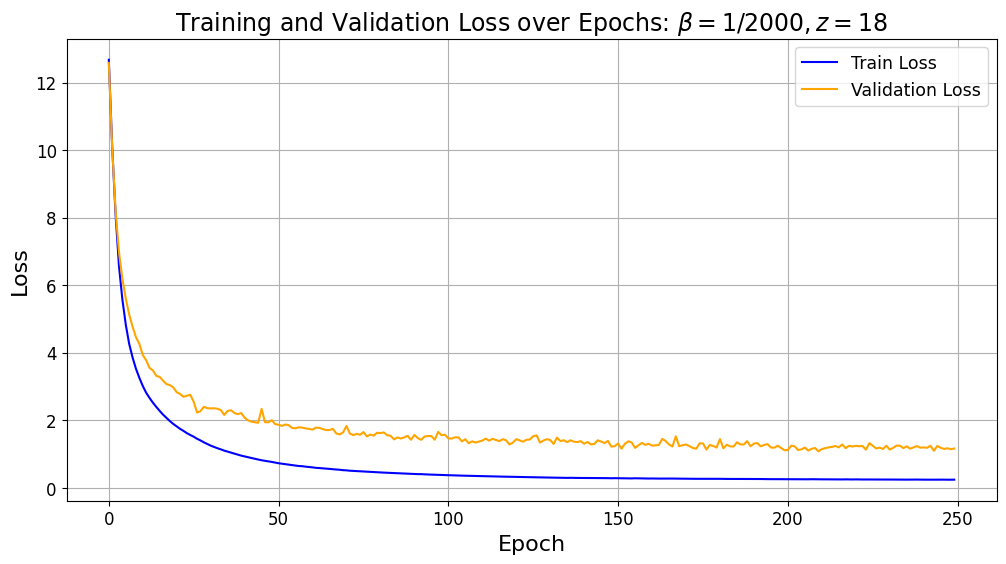

In [19]:
# plot training and validation losses over epochs

#best_model.load_state_dict(torch.load("lcpb_files/best_model_overall.pt"))

train_loss_curve = np.array(best_trial.user_attrs["mean_train_loss_curve"])
val_loss_curve = np.array(best_trial.user_attrs["mean_val_loss_curve"])
val_vae_loss_curve = np.array(best_trial.user_attrs["mean_val_vae_loss_curve"])
val_regr_loss_curve = np.array(best_trial.user_attrs["mean_val_regr_loss_curve"])

epochs = np.arange(len(train_loss_curve))

plt.figure(figsize=(12, 6))


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})

plt.plot(epochs[:250], train_loss_curve[:250], label='Train Loss', color='blue')
plt.plot(epochs[:250], val_loss_curve[:250], label='Validation Loss', color='orange')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(r"Training and Validation Loss over Epochs: $\beta=1/2000,z=18$")
plt.legend()
plt.grid(True)
plt.savefig("plots/Wind_predictions/best_model_wind_13_June_loss_beta_1_2000_z_18.png", dpi=300, bbox_inches='tight')
plt.show()

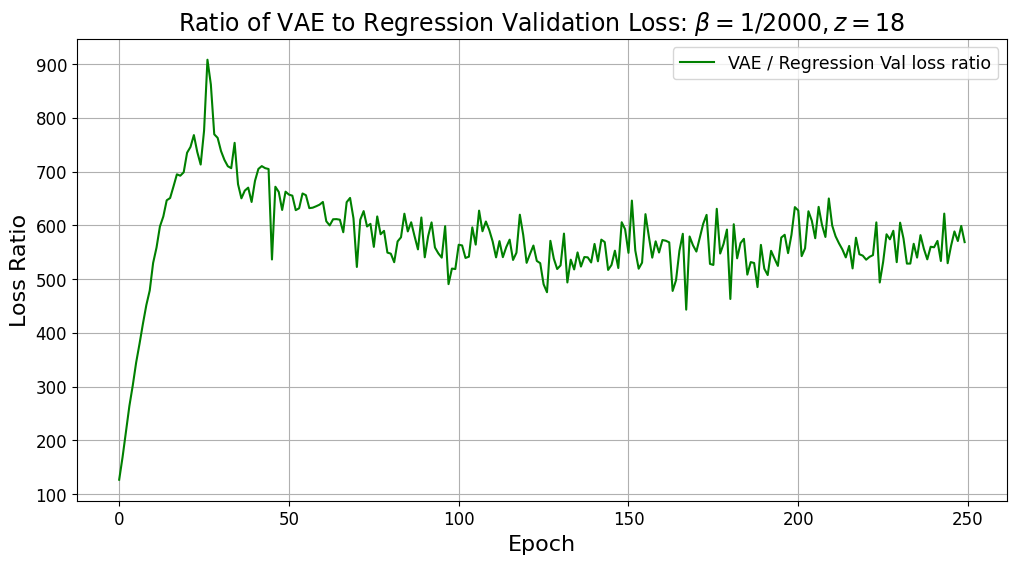

In [20]:
loss_ratio = val_vae_loss_curve / (val_regr_loss_curve + 1e-9)  # avoid division by zero

plt.figure(figsize=(12, 6))
plt.plot(epochs[:250], loss_ratio[:250], label='VAE / Regression Val loss ratio', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss Ratio")
plt.title(r"Ratio of VAE to Regression Validation Loss: $\beta=1/2000,z=18$")
plt.grid(True)
plt.legend()
plt.savefig("plots/Wind_predictions/best_model_wind_13_June_ratio_beta_1_2000_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()

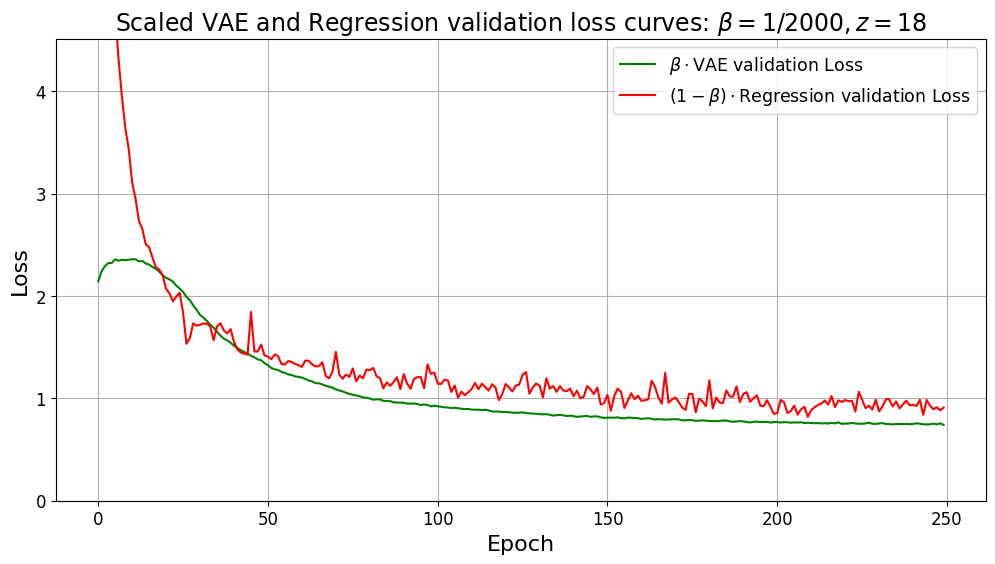

In [23]:
fig,ax= plt.subplots(figsize=(12,6))
beta = 1./700
ax.plot(epochs[:250], beta*val_vae_loss_curve[:250], label=r'$\beta \cdot$VAE validation Loss', color='green')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(r"Scaled VAE and Regression validation loss curves: $\beta=1/2000,z=18$")

ax.plot(epochs[:250], (1-beta)*val_regr_loss_curve[:250], label=r'$(1-\beta)\cdot$Regression validation Loss', color='red')
plt.ylim(0,15*np.min(val_loss_curve))
ax.grid(True)
ax.legend()
plt.savefig("plots/Wind_predictions/best_model_wind_13_June_vae_regr_losses_beta_1_2000_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()


In [24]:
best_model.eval()

num_passes= 200

mean_preds = None

for i in range(num_passes):
    regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    regr_output = regr_output.cpu()
    recon_x = recon_x.cpu()

    if mean_preds is None:
        mean_preds = regr_output
        mean_recons = recon_x
    else:
        mean_preds += (regr_output - mean_preds) / (i + 1)
        mean_recons += (recon_x - mean_recons) / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
mean_recon_x_test = mean_recons.detach().numpy()


print(mean_test_predictions)

[[0.08673016]
 [0.08426678]
 [0.15982889]
 ...
 [0.25227925]
 [0.2631629 ]
 [0.26507494]]


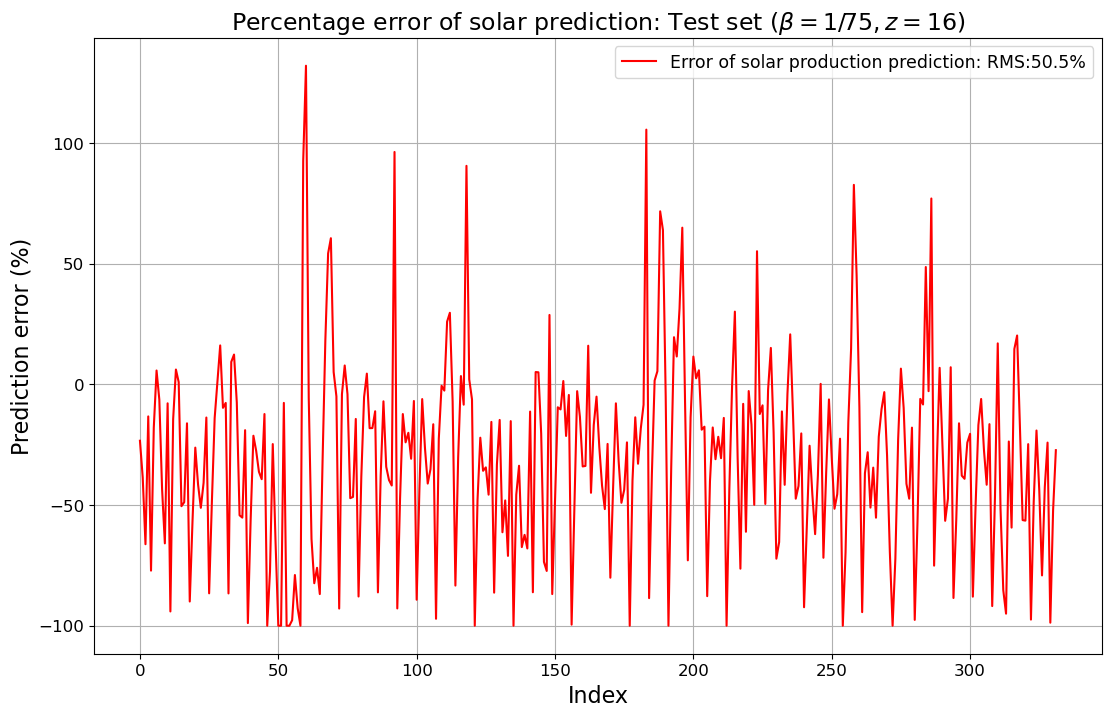

In [133]:
plt.figure(figsize=(13, 8))

Y_test_pos = Y_test[Y_test!=0]
error_solar= (mean_test_predictions[Y_test != 0][:int(len(Y_test_pos)/5)]- Y_test_pos[:int(len(Y_test_pos)/5)]) / Y_test_pos[:int(len(Y_test_pos)/5)]
plt.plot(np.arange(int(len(Y_test_pos)/5)), (error_solar*100), color='orange', label=f'Error of solar production prediction: RMS:{round(np.sqrt(np.mean((error_solar*100)**2)),1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of solar prediction: Test set ($\beta=1/250,z=??$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/error_best_model_solar_10_June_beta_1_250_z_??.png", dpi=600, bbox_inches='tight')
plt.show()





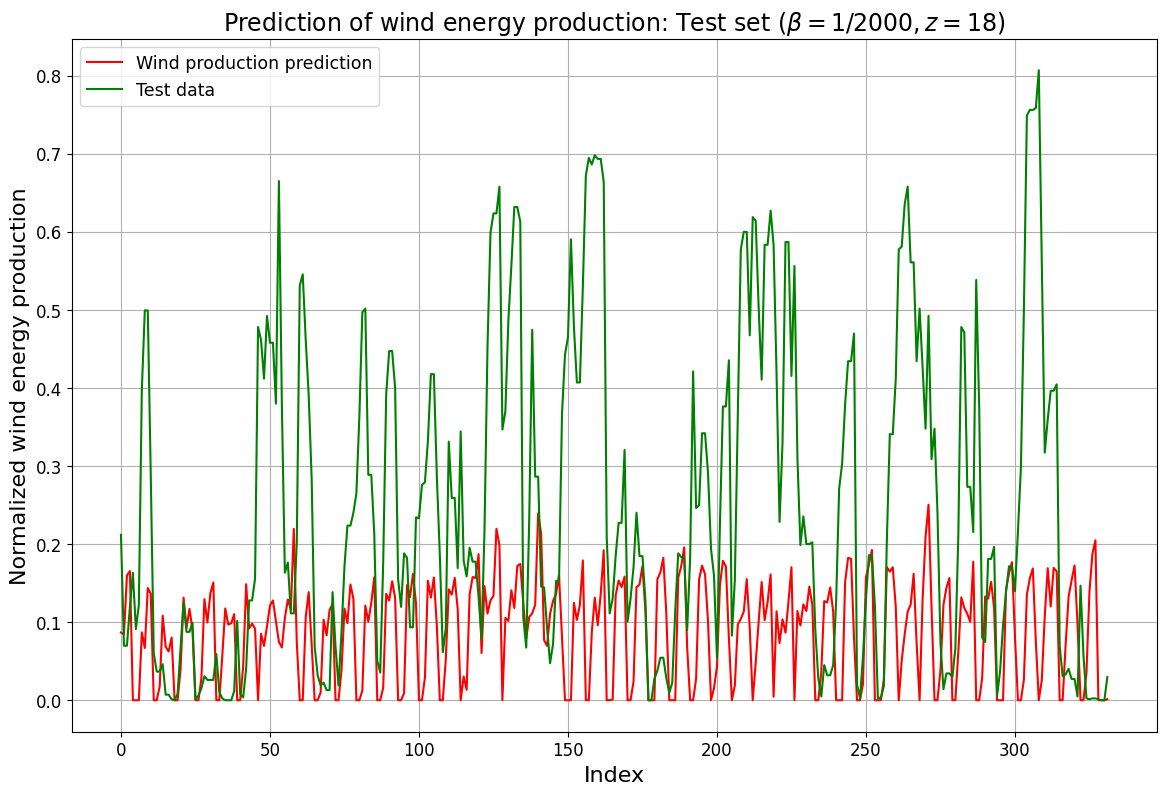

In [26]:
plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5)],color='red',label='Wind production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5)],color='green',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized wind energy production")
plt.title(r"Prediction of wind energy production: Test set ($\beta=1/2000,z=18$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Wind_predictions/best_model_wind_13_June_beta_1_2000_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()




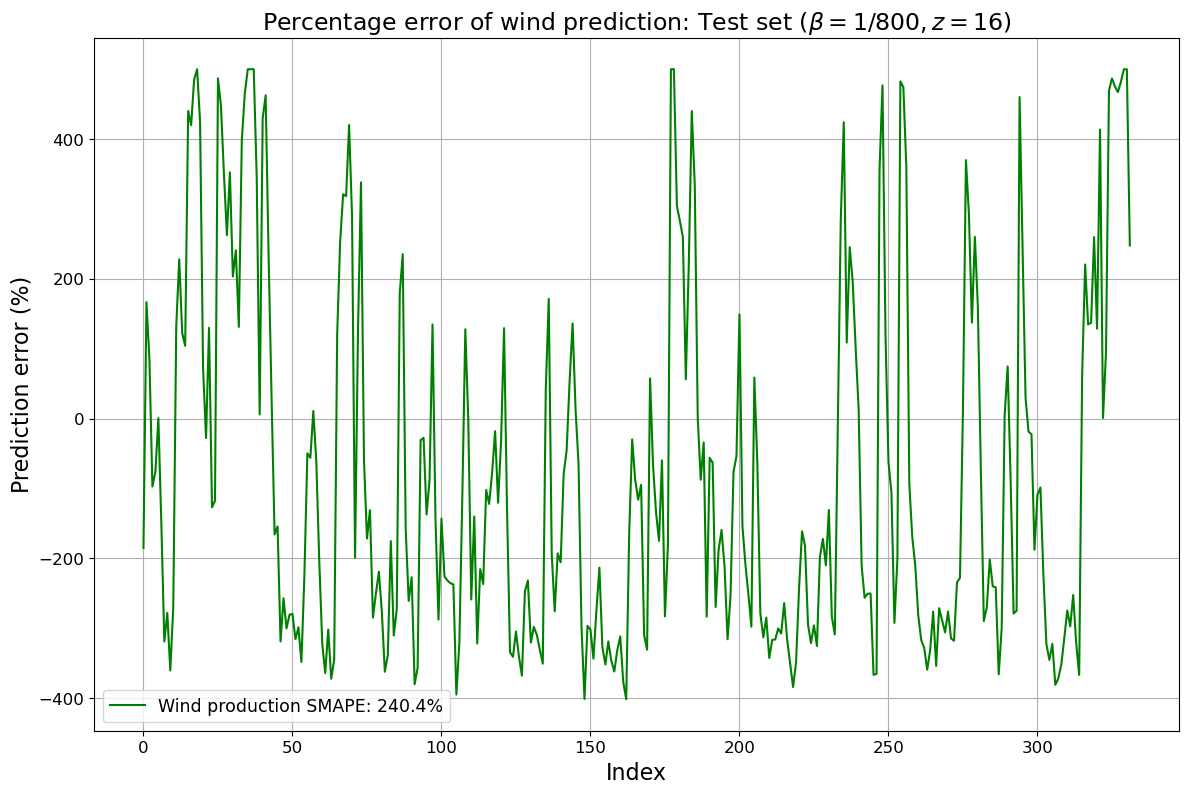

In [124]:
plt.figure(figsize=(13, 8))

Y_test_pos = Y_test[Y_test!=0]
error_wind= (mean_test_predictions[Y_test != 0][:int(len(Y_test_pos)/5)]- Y_test_pos[:int(len(Y_test_pos)/5)]) / Y_test_pos[:int(len(Y_test_pos)/5)]
plt.plot(np.arange(int(len(Y_test_pos)/5)), (error_wind*100), color='green', label=f'Error of wind production prediction: RMS:{round(np.sqrt(np.mean((error_wind*100)**2)),1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of wind prediction: Test set ($\beta=1/2000,z=18$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Wind_predictions/error_best_model_wind_13_June_beta_1_2000_z_18_new.png", dpi=600, bbox_inches='tight')
plt.show()



In [ ]:
plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5)],color='red',label='Hydro-electric production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5)],color='blue',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized hydro-electric energy production")
plt.title(r"Prediction of hydro-electric energy production: Test set ($\beta=1/2000,z=18$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Hydro_predictions/best_model_hydro_22_June_beta_1_2000_z_18_new.png", dpi=600, bbox_inches='tight')
plt.show()

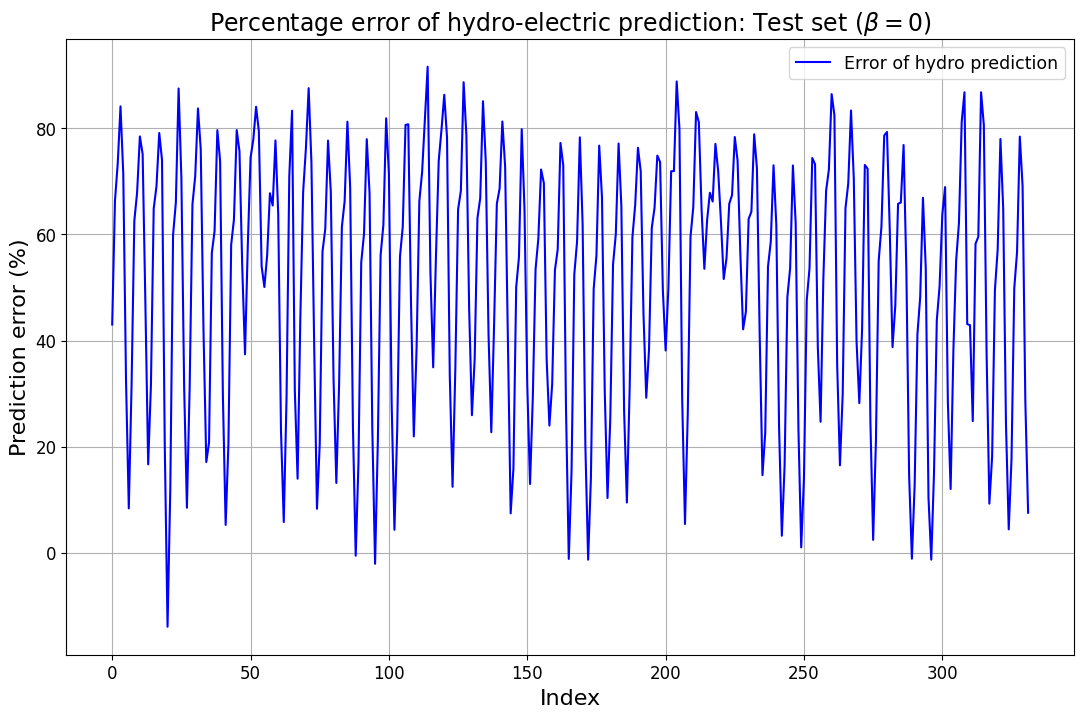

<Figure size 640x480 with 0 Axes>

In [71]:
plt.figure(figsize=(13, 8))

Y_test_pos = Y_test[Y_test!=0]
error_hydro= (mean_test_predictions[Y_test != 0][:int(len(Y_test_pos)/5)]- Y_test_pos[:int(len(Y_test_pos)/5)]) / Y_test_pos[:int(len(Y_test_pos)/5)]
plt.plot(np.arange(int(len(Y_test_pos)/5)), (error_hydro*100), color='blue', label=f'Error of hydro production prediction: RMS:{round(np.sqrt(np.mean((error_hydro*100)**2)),1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of wind prediction: Test set ($\beta=1/2000,z=18$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Wind_predictions/error_best_model_wind_13_June_beta_1_2000_z_18_new.png", dpi=600, bbox_inches='tight')
plt.show()



## **Input reconstruction: visualization**

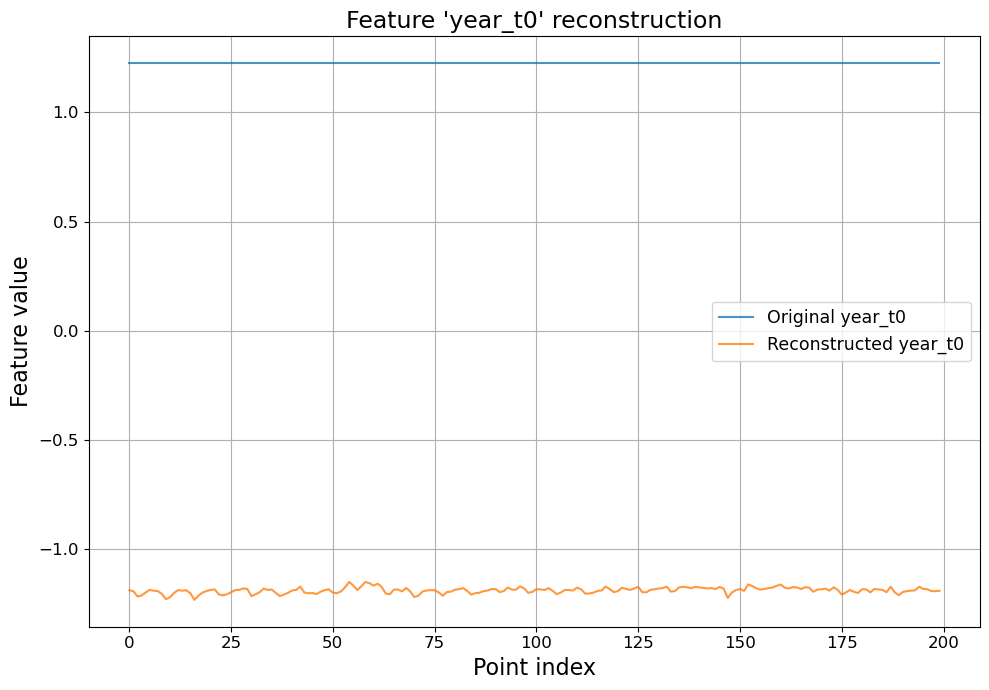

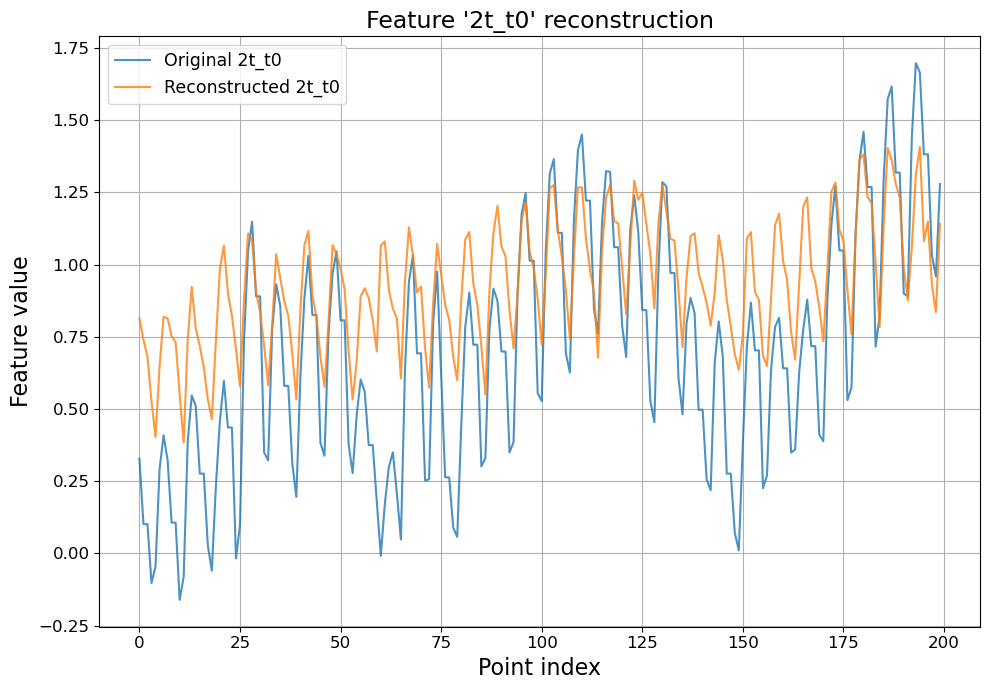

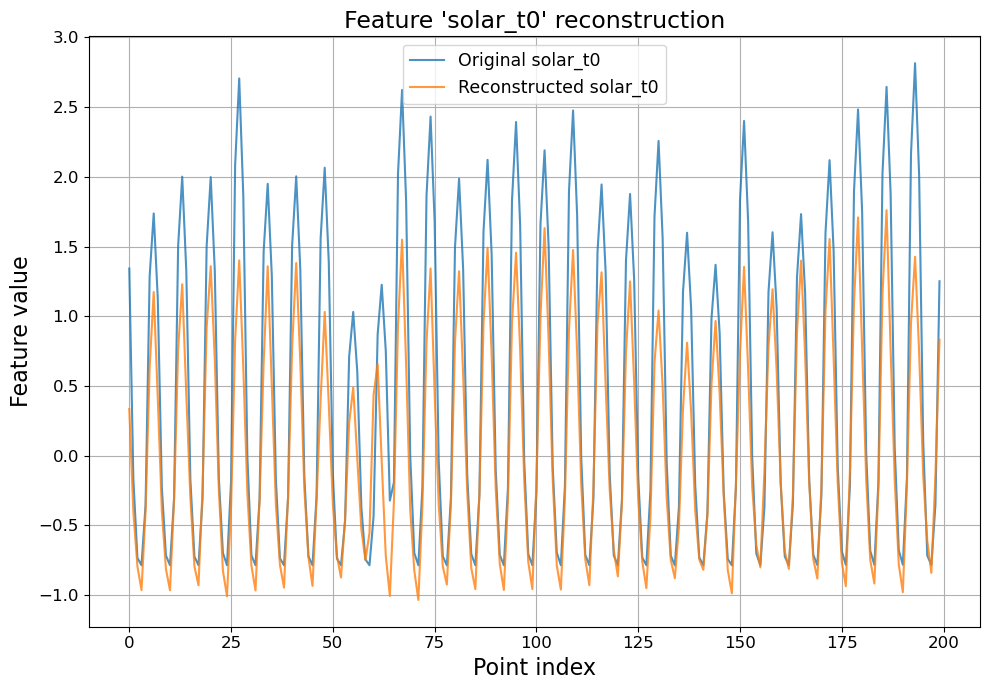

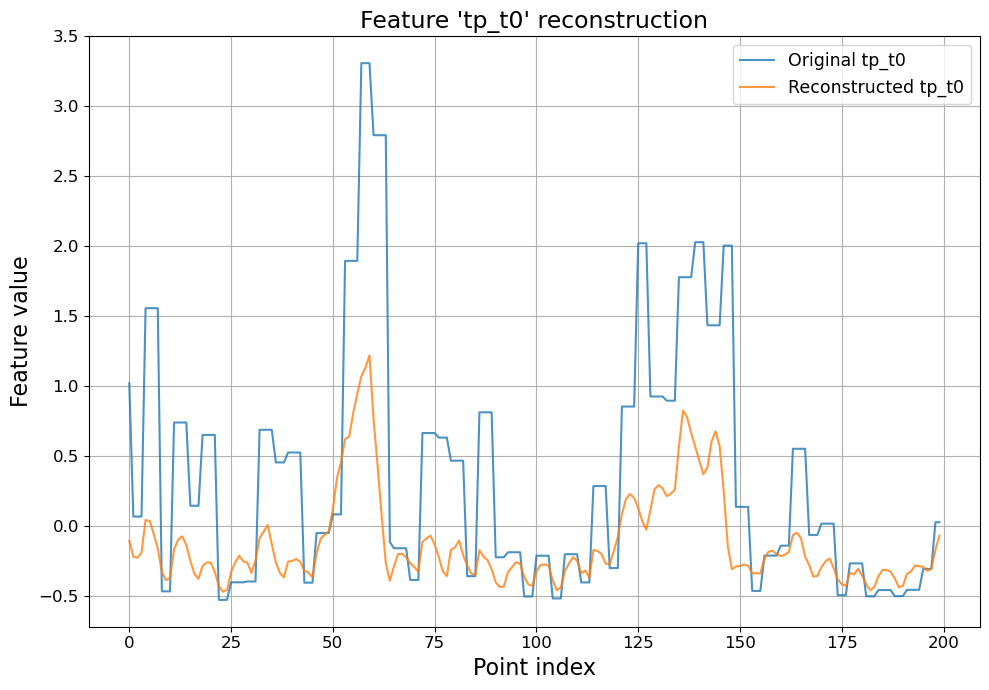

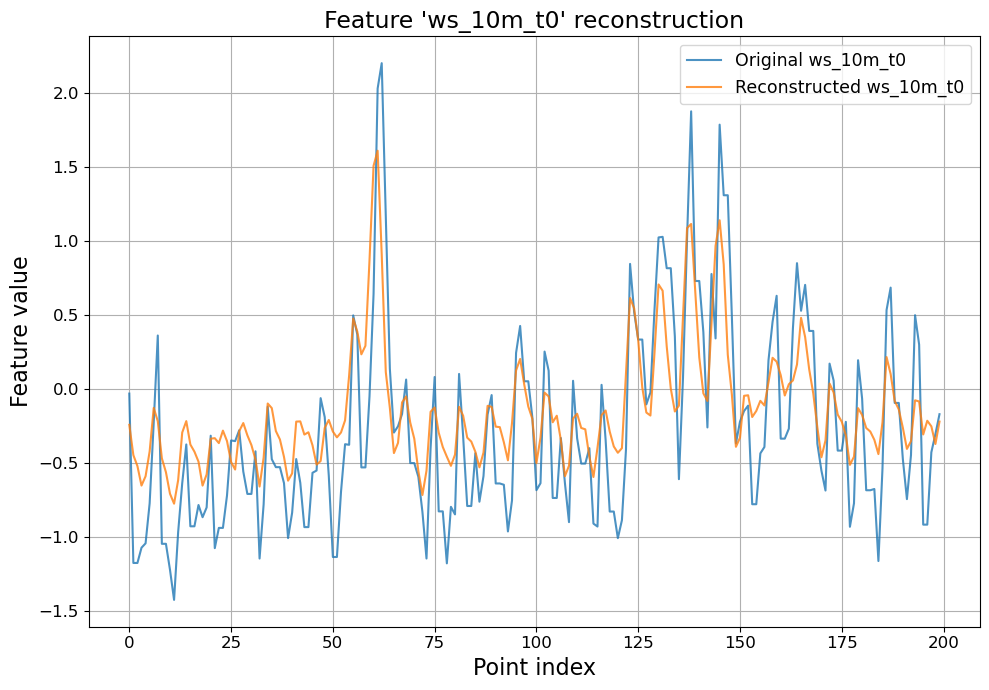

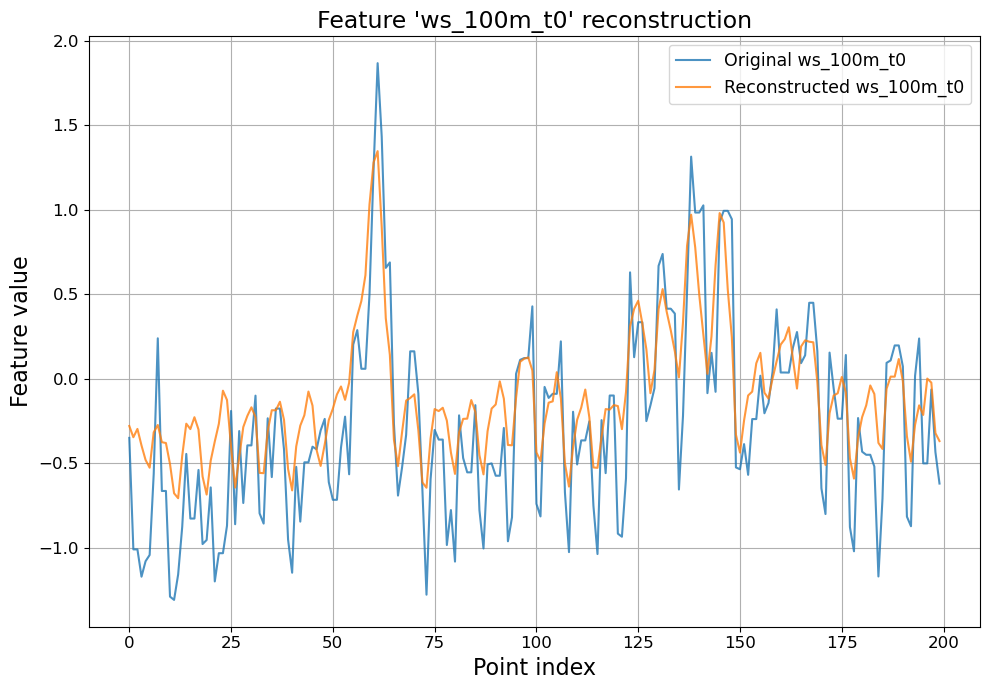

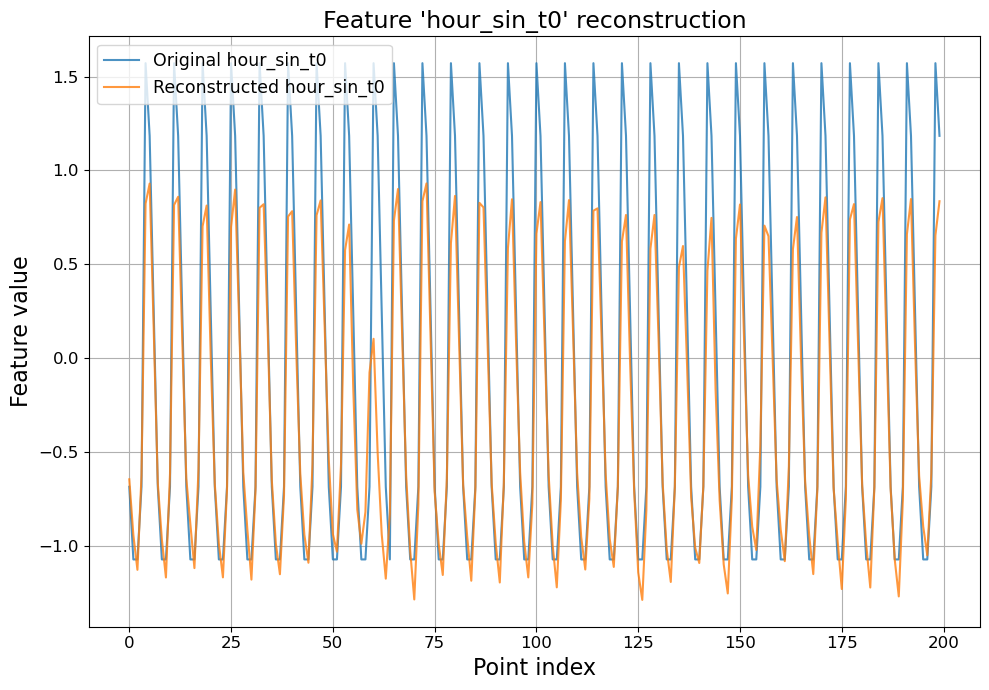

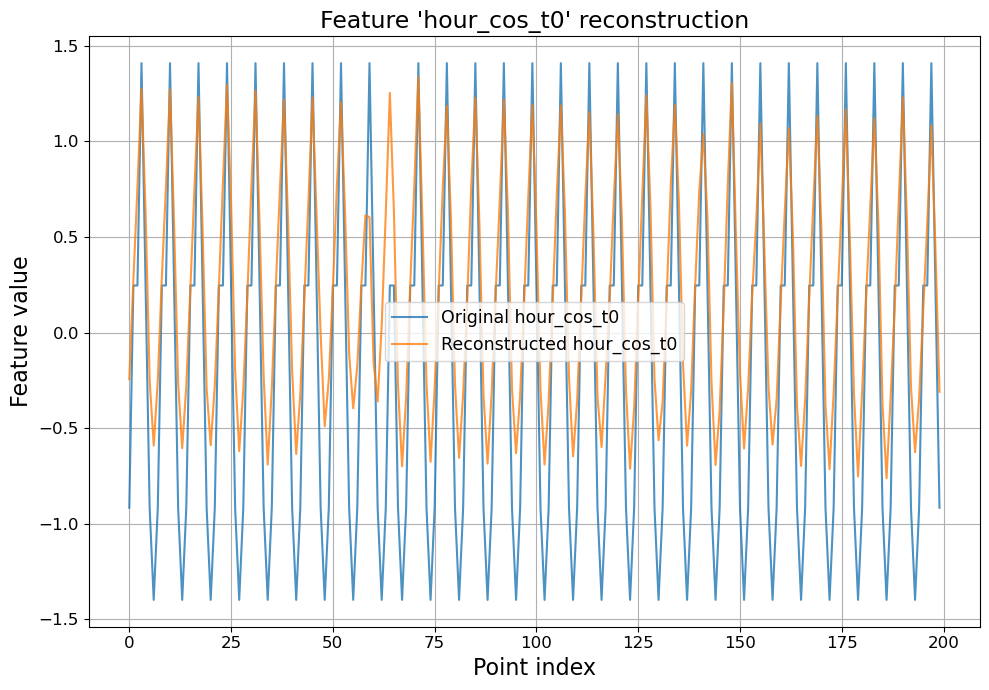

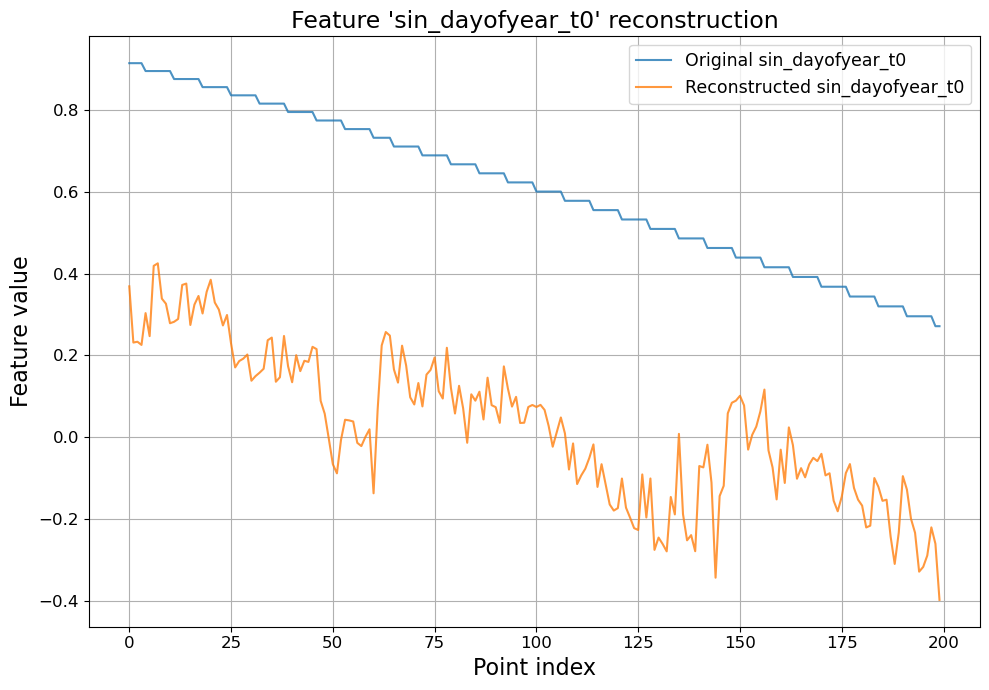

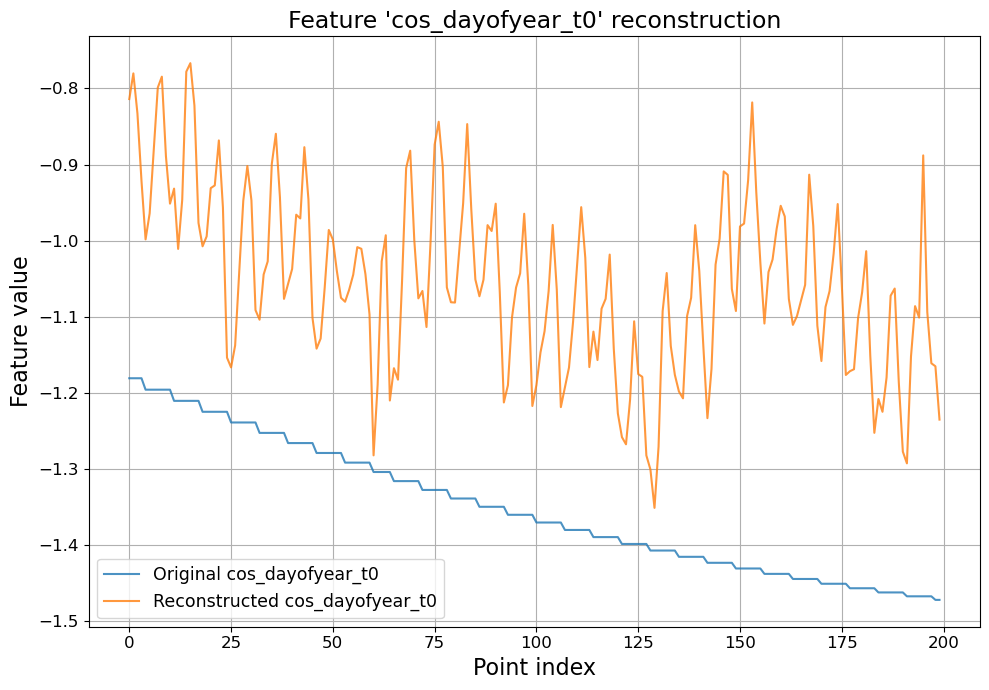

In [126]:
original_all = X_test
reconstructed_all = mean_recon_x_test

# Feature names from dataframe (excluding 'timestamp')
feature_names = df_features.drop(columns=['timestamp']).columns.tolist()

# Select features by index
features_to_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# How many time steps to plot
points_to_plot = 200
dummy_x = np.arange(points_to_plot)

for feature_idx in features_to_plot:
    plt.figure(figsize=(10, 7))

    plt.plot(dummy_x,
             original_all[:points_to_plot, feature_idx],
             alpha=0.8,
             label=f'Original {feature_names[feature_idx]}')

    plt.plot(dummy_x,
             reconstructed_all[:points_to_plot, feature_idx],
             alpha=0.8,
             label=f'Reconstructed {feature_names[feature_idx]}')

    plt.xlabel("Point index")
    plt.ylabel("Feature value")
    plt.title(f"Feature '{feature_names[feature_idx]}' reconstruction")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    filename = f'plots/VAE_Reconstruction/best_model_23_June_feature_{feature_idx}_beta_1_550_z_18_solar_2VAElayers.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

## Search for best $\beta$ parameter
(for either solar,wind,hydro)

In [10]:
# fix previous best hyper parameters and find best beta

def objective(trial):

    def get_activation(name):
        return {
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU()}[name]

    beta = trial.suggest_float("beta",200,3000, step=100) # choose a reasonable range according to previous results
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 250
    batch_size = 16
    num_folds = 2
    early_stop_patience = 35
    tscv = TimeSeriesSplit(n_splits= num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    best_val_loss = float('inf')
    best_model_state = None

    fold_val_regr_curves = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]
        
        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)
        
        lambda_tik = 3.9022620018270354e-05
        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            hidden_dim1=256,
            hidden_dim2=64,
            latent_dim=18,
            hidden_dim3=256,
            vae_activation=get_activation('relu'),
            N1=256,
            N2=64,
            No=Y_train_fold.shape[1],
            activation=get_activation('relu'),
            lambda_tik=lambda_tik
        ).to(device)

        lr = 5.937967528097218e-05
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience= 20)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        no_improve_counter = 0
        best_fold_loss = float('inf')
        fold_val_regr_curve = []

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1-1./beta) * regr_loss + 1./beta*vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - 1. / beta) * regr_loss + 1. / beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            epoch_train_losses[epoch] += (train_loss_epoch) / num_folds
            epoch_val_losses[epoch] += (val_loss_epoch) / num_folds
            epoch_val_vae_losses[epoch] += (val_vae_loss_epoch) / num_folds
            epoch_val_regr_losses[epoch] += (val_regr_loss_epoch) / num_folds

            fold_val_regr_curve.append(val_regr_loss_epoch)

            print(f"Epoch [{epoch + 1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_loss_epoch < best_fold_loss: # early stopping
                best_fold_loss = val_loss_epoch
                no_improve_counter = 0
            else:
                no_improve_counter += 1
                if no_improve_counter >= early_stop_patience:
                    print(f"Early stopping at epoch {epoch + 1} in fold {fold + 1}")
                    break

            if val_loss_epoch < best_val_loss:
                best_val_loss = val_loss_epoch
                best_model_state = model.state_dict()

        fold_val_regr_curves.append(fold_val_regr_curve)

    model_path = f"weights_VAE_Regression/Single_solar/model_trial_{trial.number}.pt"
    torch.save(best_model_state, model_path)
    trial.set_user_attr("model_path", model_path)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    trial.set_user_attr("final_vae_loss", epoch_val_vae_losses[-1])
    trial.set_user_attr("final_regr_loss", epoch_val_regr_losses[-1])

    mean_last10_regr_losses = []
    for curve in fold_val_regr_curves:
        if len(curve) >= 10:
            mean_last10_regr_losses.append(np.mean(curve[-10:]))
        else:
            mean_last10_regr_losses.append(np.mean(curve))

    return float(np.mean(mean_last10_regr_losses))


In [ ]:
from tqdm import tqdm
n_trials = 30

study = optuna.create_study( study_name="wind_study_beta_14June", direction="minimize",
    storage="sqlite:///wind_14June_optuna.db",
    load_if_exists=True,pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=125))

for _ in tqdm(range(n_trials), desc="Optuna Trials", unit="trial"):
    study.optimize(objective, n_trials=1,n_jobs=-1,catch=(Exception,))

[I 2025-06-15 23:23:16,913] Using an existing study with name 'wind_study_beta_14June' instead of creating a new one.
Optuna Trials:   0%|                                                                          | 0/30 [00:00<?, ?trial/s]

Epoch [1/250] - Total val loss: 34.5178, VAE: 676.4073, Regr: 33.5995
Epoch [2/250] - Total val loss: 27.0533, VAE: 703.6461, Regr: 26.0853
Epoch [3/250] - Total val loss: 21.3950, VAE: 735.3892, Regr: 20.3735
Epoch [4/250] - Total val loss: 17.2569, VAE: 744.8091, Regr: 16.2161
Epoch [5/250] - Total val loss: 14.3999, VAE: 747.2159, Regr: 13.3516
Epoch [6/250] - Total val loss: 12.4033, VAE: 750.4642, Regr: 11.3474
Epoch [7/250] - Total val loss: 10.9305, VAE: 750.2802, Regr: 9.8728
Epoch [8/250] - Total val loss: 9.9508, VAE: 748.5312, Regr: 8.8941
Epoch [9/250] - Total val loss: 9.2841, VAE: 752.9914, Regr: 8.2202
Epoch [10/250] - Total val loss: 8.5882, VAE: 754.9391, Regr: 7.5205
Epoch [11/250] - Total val loss: 8.1659, VAE: 759.7275, Regr: 7.0907
Epoch [12/250] - Total val loss: 7.7261, VAE: 763.1147, Regr: 6.6454
Epoch [13/250] - Total val loss: 7.3642, VAE: 761.9388, Regr: 6.2847
Epoch [14/250] - Total val loss: 7.0037, VAE: 773.2040, Regr: 5.9076
Epoch [15/250] - Total val los

[I 2025-06-16 10:51:06,525] Trial 9 finished with value: 2.027852726773285 and parameters: {'beta': 700.0}. Best is trial 6 with value: 0.9032029687614588.
Optuna Trials:   3%|█▊                                                      | 1/30 [11:27:49<332:26:58, 41269.61s/trial]

Epoch [1/250] - Total val loss: 31.2248, VAE: 672.7241, Regr: 31.0035
Epoch [2/250] - Total val loss: 24.4219, VAE: 702.3171, Regr: 24.1881
Epoch [3/250] - Total val loss: 19.2718, VAE: 731.9613, Regr: 19.0260
Epoch [4/250] - Total val loss: 15.5881, VAE: 742.4881, Regr: 15.3374
Epoch [5/250] - Total val loss: 13.0897, VAE: 755.1675, Regr: 12.8338
Epoch [6/250] - Total val loss: 11.3391, VAE: 753.3883, Regr: 11.0831
Epoch [7/250] - Total val loss: 9.9906, VAE: 759.2272, Regr: 9.7321
Epoch [8/250] - Total val loss: 9.0575, VAE: 763.6224, Regr: 8.7972
Epoch [9/250] - Total val loss: 8.4111, VAE: 766.5858, Regr: 8.1495
Epoch [10/250] - Total val loss: 7.9447, VAE: 769.1196, Regr: 7.6822
Epoch [11/250] - Total val loss: 7.4948, VAE: 774.8872, Regr: 7.2301
Epoch [12/250] - Total val loss: 7.0699, VAE: 775.4369, Regr: 6.8049
Epoch [13/250] - Total val loss: 6.6822, VAE: 779.7655, Regr: 6.4155
Epoch [14/250] - Total val loss: 6.3824, VAE: 786.8473, Regr: 6.1132
Epoch [15/250] - Total val loss

[I 2025-06-16 10:59:06,457] Trial 10 finished with value: 2.8442634101313864 and parameters: {'beta': 2900.0}. Best is trial 6 with value: 0.9032029687614588.
Optuna Trials:   7%|███▋                                                    | 2/30 [11:35:49<134:21:58, 17275.68s/trial]

...

Epoch [91/250] - Total val loss: 4.4708, VAE: 613.9946, Regr: 4.1498
Early stopping at epoch 91 in fold 2
Epoch [1/250] - Total val loss: 31.8560, VAE: 686.2610, Regr: 31.4194
Epoch [2/250] - Total val loss: 24.8450, VAE: 715.2611, Regr: 24.3844
Epoch [3/250] - Total val loss: 19.7620, VAE: 740.2484, Regr: 19.2814
Epoch [4/250] - Total val loss: 16.0277, VAE: 749.8882, Regr: 15.5381
Epoch [5/250] - Total val loss: 13.2871, VAE: 750.6414, Regr: 12.7952
Epoch [6/250] - Total val loss: 11.4030, VAE: 753.5540, Regr: 10.9079
Epoch [7/250] - Total val loss: 10.1083, VAE: 755.0333, Regr: 9.6113
Epoch [8/250] - Total val loss: 9.2198, VAE: 759.2039, Regr: 8.7194
Epoch [9/250] - Total val loss: 8.5087, VAE: 764.9115, Regr: 8.0040
Epoch [10/250] - Total val loss: 8.0054, VAE: 775.1997, Regr: 7.4936
Epoch [11/250] - Total val loss: 7.5787, VAE: 782.9388, Regr: 7.0614
Epoch [12/250] - Total val loss: 7.1952, VAE: 787.5654, Regr: 6.6746
Epoch [13/250] - Total val loss: 6.8183, VAE: 787.3199, Regr: 

[I 2025-06-16 12:59:23,347] Trial 26 finished with value: 1.1052546021227034 and parameters: {'beta': 1500.0}. Best is trial 14 with value: 0.8833242061125824.
Optuna Trials:  60%|███████████████████████████████████▍                       | 18/30 [13:36:06<1:32:24, 462.01s/trial]

Epoch [110/250] - Total val loss: 2.1712, VAE: 570.1990, Regr: 1.7923
Early stopping at epoch 110 in fold 2
Epoch [1/250] - Total val loss: 30.7725, VAE: 678.2660, Regr: 30.3914
Epoch [2/250] - Total val loss: 24.2174, VAE: 702.0815, Regr: 23.8184
Epoch [3/250] - Total val loss: 19.2022, VAE: 728.2217, Regr: 18.7849
Epoch [4/250] - Total val loss: 15.7292, VAE: 741.0387, Regr: 15.3023
Epoch [5/250] - Total val loss: 13.2052, VAE: 745.0082, Regr: 12.7745
Epoch [6/250] - Total val loss: 11.4818, VAE: 748.3774, Regr: 11.0480
Epoch [7/250] - Total val loss: 10.2910, VAE: 755.0364, Regr: 9.8526
Epoch [8/250] - Total val loss: 9.4384, VAE: 758.1617, Regr: 8.9977
Epoch [9/250] - Total val loss: 8.7907, VAE: 763.0422, Regr: 8.3468
Epoch [10/250] - Total val loss: 8.2478, VAE: 765.9386, Regr: 7.8018
Epoch [11/250] - Total val loss: 7.8479, VAE: 774.2542, Regr: 7.3968
Epoch [12/250] - Total val loss: 7.5932, VAE: 775.8488, Regr: 7.1410
Epoch [13/250] - Total val loss: 7.2431, VAE: 781.8413, Regr

[I 2025-06-16 13:05:48,270] Trial 27 finished with value: 2.814682350972359 and parameters: {'beta': 1700.0}. Best is trial 14 with value: 0.8833242061125824.
Optuna Trials:  63%|█████████████████████████████████████▎                     | 19/30 [13:42:31<1:20:27, 438.85s/trial]

Epoch [117/250] - Total val loss: 3.3609, VAE: 543.7100, Regr: 3.0429
Early stopping at epoch 117 in fold 2
Epoch [1/250] - Total val loss: 33.6021, VAE: 682.3747, Regr: 33.2930
Epoch [2/250] - Total val loss: 26.5620, VAE: 715.8330, Regr: 26.2336
Epoch [3/250] - Total val loss: 20.9595, VAE: 740.2641, Regr: 20.6168
Epoch [4/250] - Total val loss: 16.8078, VAE: 750.3592, Regr: 16.4583
Epoch [5/250] - Total val loss: 13.9392, VAE: 757.1959, Regr: 13.5851
Epoch [6/250] - Total val loss: 11.8575, VAE: 760.5208, Regr: 11.5009
Epoch [7/250] - Total val loss: 10.3924, VAE: 753.4515, Regr: 10.0384
Epoch [8/250] - Total val loss: 9.4374, VAE: 753.9784, Regr: 9.0827
Epoch [9/250] - Total val loss: 8.5542, VAE: 762.1185, Regr: 8.1952
Epoch [10/250] - Total val loss: 7.9744, VAE: 767.0561, Regr: 7.6128
Epoch [11/250] - Total val loss: 7.4705, VAE: 770.3729, Regr: 7.1070
Epoch [12/250] - Total val loss: 7.0412, VAE: 775.2746, Regr: 6.6752


## **Final training and results: solar**

In [55]:
# final training for the best hyper-parameters found

import os
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
lambda_tik=3.036728864553219e-05
best_model = VAE_Regression(
     input_dim=X_train_tensor.shape[1],
     hidden_dim1=128,
     hidden_dim2=128,
     latent_dim=18,
     hidden_dim3=256,
     vae_activation=get_activation('relu'),
     N1=256,
     N2=64,
     No=Y_train_tensor.shape[1],
     activation=get_activation('relu'),
     lambda_tik=lambda_tik).to(device)

train_loader = DataLoader(TensorDataset(X_train_tensor, Y_train_tensor), batch_size=16, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  Y_test_tensor),  batch_size=16, shuffle=False)

num_epochs = 250
beta       = 1/550.0 # best previously found
patience   = 35

train_curve     = []
test_curve      = []
test_vae_curve  = []
test_regr_curve = []

optimizer = torch.optim.Adam(best_model.parameters(), lr=0.00011695038421675327)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=20)

best_test = float("inf")
no_imp    = 0
best_state= None

for ep in range(num_epochs):
    best_model.train()
    train_sum = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred, recon, mu, logvar, _ = best_model(xb)
        vl = best_model.VAE_loss(recon, xb, mu, logvar)[0]
        rl = best_model.regression_loss(yb, pred, lambda_tik)
        loss = (1-beta)*rl + beta*vl
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(best_model.parameters(), 1.0)
        optimizer.step()
        train_sum += loss.item()
    train_curve.append(train_sum/len(train_loader))

    best_model.eval()
    t_sum = v_sum = r_sum = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred, recon, mu, logvar, _ = best_model(xb)
            vl = best_model.VAE_loss(recon, xb, mu, logvar)[0].item()
            rl = best_model.regression_loss(yb, pred,lambda_tik).item()
            t_sum += (1-beta)*rl + beta*vl
            v_sum += vl
            r_sum += rl
    te = t_sum/len(test_loader)
    tv = v_sum/len(test_loader)
    tr = r_sum/len(test_loader)
    test_curve.append(te)
    test_vae_curve.append(tv)
    test_regr_curve.append(tr)

    print(f"Epoch {ep+1}/{num_epochs} - Val Total: {te:.4f}, VAE: {tv:.4f}, Regr: {tr:.4f}")

    
    if tr < best_test:
        best_test = tr
        best_state= best_model.state_dict()
        no_imp    = 0
    else:
        no_imp += 1
        if no_imp >= patience:
            break

best_model.load_state_dict(best_state)
os.makedirs("best_Regr_models/Single_solar", exist_ok=True)
torch.save(best_state, "best_Regr_models/Single_solar/best_model_solar_23June_FINAL.pt")

train_loss_curve    = np.array(train_curve)
val_loss_curve      = np.array(test_curve)
val_vae_loss_curve  = np.array(test_vae_curve)
val_regr_loss_curve = np.array(test_regr_curve)


Epoch 1/250 - Val Total: 24.2174, VAE: 1722.7148, Regr: 21.1236
Epoch 2/250 - Val Total: 14.2704, VAE: 1669.3098, Regr: 11.2558
Epoch 3/250 - Val Total: 10.0625, VAE: 1555.5021, Regr: 7.2475
Epoch 4/250 - Val Total: 7.2460, VAE: 1274.2643, Regr: 4.9381
Epoch 5/250 - Val Total: 5.4790, VAE: 1084.6907, Regr: 3.5132
Epoch 6/250 - Val Total: 4.4894, VAE: 1014.8234, Regr: 2.6491
Epoch 7/250 - Val Total: 3.8792, VAE: 968.0826, Regr: 2.1229
Epoch 8/250 - Val Total: 3.4426, VAE: 882.0104, Regr: 1.8423
Epoch 9/250 - Val Total: 2.9893, VAE: 734.7310, Regr: 1.6564
Epoch 10/250 - Val Total: 2.6290, VAE: 626.8571, Regr: 1.4920
Epoch 11/250 - Val Total: 2.4097, VAE: 582.8680, Regr: 1.3524
Epoch 12/250 - Val Total: 2.2062, VAE: 558.3302, Regr: 1.1932
Epoch 13/250 - Val Total: 2.0111, VAE: 534.7558, Regr: 1.0407
Epoch 14/250 - Val Total: 1.8134, VAE: 504.0019, Regr: 0.8987
Epoch 15/250 - Val Total: 1.6417, VAE: 479.2937, Regr: 0.7717
Epoch 16/250 - Val Total: 1.5114, VAE: 465.6850, Regr: 0.6659
Epoch 

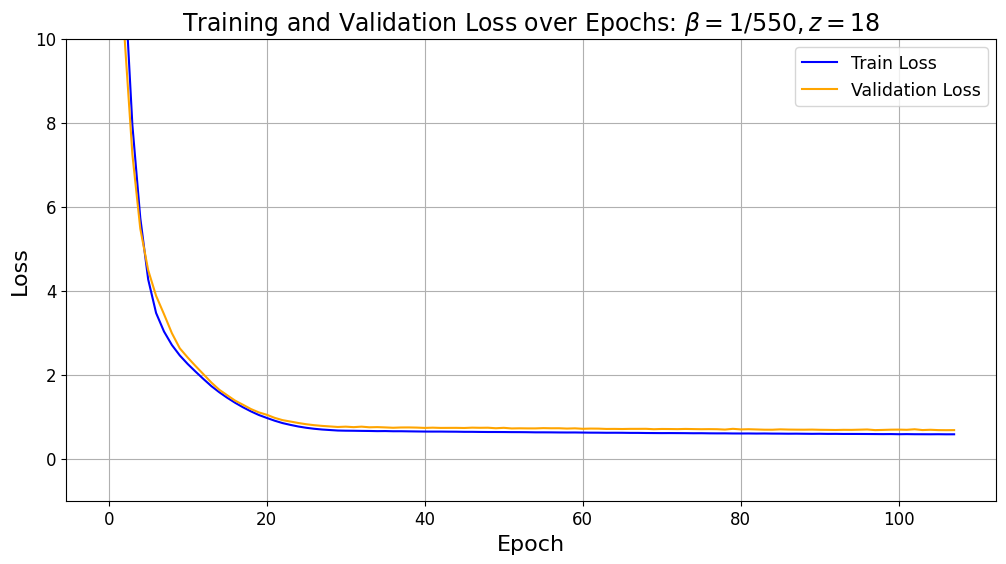

In [67]:
epochs = np.arange(len(train_loss_curve[train_loss_curve!=0]))

plt.figure(figsize=(12, 6))


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})

plt.plot(epochs, train_loss_curve[train_loss_curve!=0], label='Train Loss', color='blue')
plt.plot(epochs, val_loss_curve[val_loss_curve!=0], label='Validation Loss', color='orange')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(r"Training and Validation Loss over Epochs: $\beta=1/550,z=18$")
plt.legend()
plt.ylim(-1,10)
plt.grid(True)
plt.savefig("plots/Solar_predictions/best_model_solar_23_June_loss_beta_1_550_z_18.png", dpi=300, bbox_inches='tight')
plt.show()

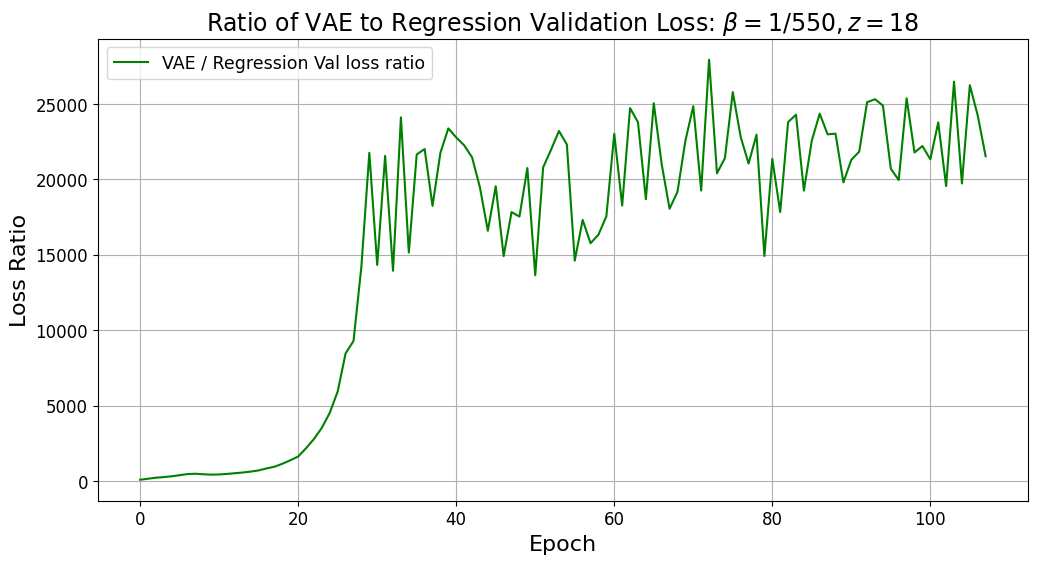

In [68]:
loss_ratio = val_vae_loss_curve / (val_regr_loss_curve + 1e-9)  # avoid division by zero

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_ratio[:len(epochs)], label='VAE / Regression Val loss ratio', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss Ratio")
plt.title(r"Ratio of VAE to Regression Validation Loss: $\beta=1/550,z=18$")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/best_model_solar_23_June_Ratio_beta_1_550_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()

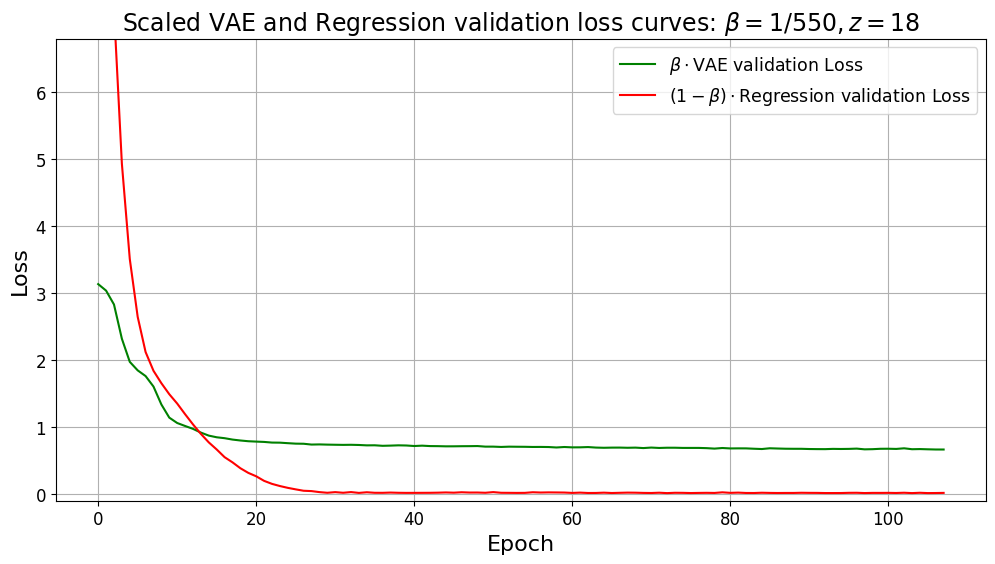

In [69]:
fig,ax= plt.subplots(figsize=(12,6))
beta = 1./550
ax.plot(epochs, beta*val_vae_loss_curve[:len(epochs)], label=r'$\beta \cdot$VAE validation Loss', color='green')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(r"Scaled VAE and Regression validation loss curves: $\beta=1/550,z=18$")

ax.plot(epochs, (1-beta)*val_regr_loss_curve[:len(epochs)], label=r'$(1-\beta)\cdot$Regression validation Loss', color='red')
plt.ylim(-0.1,10*np.min(val_loss_curve[:len(epochs)]))
ax.grid(True)
ax.legend()
plt.savefig("plots/Solar_predictions/best_model_solar_23_June_Vae_Regr_Losses_beta_1_550_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()


## YOU CAN SKIP THIS!

In [12]:
# code to restore a previously saved session if needed !

input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_activation(name):
    return {
        "relu": torch.nn.ReLU(),
        "sigmoid": torch.nn.Sigmoid(),
        "leaky_relu": torch.nn.LeakyReLU()
    }[name]

# r-ecreate the model with fixed parameters
best_model = VAE_Regression(
    input_dim=input_dim,
    hidden_dim1=128,
    hidden_dim2=128,
    latent_dim=18,
    hidden_dim3=256,
    vae_activation=get_activation('relu'),
    N1=256,
    N2=64,
    No=output_dim,
    activation=get_activation('relu'),
    lambda_tik=3.036728864553219e-05
).to(device)

# Load model weights (from trial 0 path)
model_path = "best_Regr_models/Single_solar/best_model_solar_12June_hyperparams_1.pt"
best_model.load_state_dict(torch.load(model_path))


/tmp/ipykernel_3875/3177231708.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(model_path))


<All keys matched successfully>

In [13]:
# code to restore a previously saved session if needed
best_model = VAE_Regression(
    input_dim=X_test_tensor.shape[1],  # your input dim
    hidden_dim1=128,
    hidden_dim2=128,
    latent_dim=18,
    hidden_dim3=256,
    vae_activation=torch.nn.ReLU(),
    N1=256,
    N2=64,
    No=Y_test_tensor.shape[1],  # output dim
    activation=torch.nn.ReLU(),
    lambda_tik=3.60102373063772e-05
).to(device)

# Load saved state dict from trial 3
model_path = "weights_VAE_Regression/Single_solar/model_trial_3.pt"
best_model.load_state_dict(torch.load(model_path, map_location=device))
best_model.eval()

/tmp/ipykernel_3875/3117635570.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(model_path, map_location=device))


VAE_Regression(
  (vae): VAE(
    (fc1): Linear(in_features=90, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (fc_mu): Linear(in_features=128, out_features=18, bias=True)
    (fc_logvar): Linear(in_features=128, out_features=18, bias=True)
    (fc3): Linear(in_features=18, out_features=256, bias=True)
    (fc4): Linear(in_features=256, out_features=90, bias=True)
    (activation): ReLU()
  )
  (regression): Net(
    (fc1): Linear(in_features=18, out_features=256, bias=True)
    (batch1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (drop1): Dropout(p=0.1, inplace=False)
    (fc2): Linear(in_features=256, out_features=64, bias=True)
    (batch2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (drop2): Dropout(p=0.1, inplace=False)
    (out): Linear(in_features=64, out_features=1, bias=True)
    (act): ReLU()
  )
)

## Predictions evaluation

In [56]:
# predictions

best_model.eval()

num_passes= 100

mean_preds = None

for i in range(num_passes):
    regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    regr_output = regr_output.cpu()
    recon_x = recon_x.cpu()

    if mean_preds is None:
        mean_preds = regr_output
        mean_recons = recon_x
    else:
        mean_preds += (regr_output - mean_preds) / (i + 1)
        mean_recons += (recon_x - mean_recons) / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
mean_recon_x_test = mean_recons.detach().numpy()



print(mean_test_predictions)


[[0.18288541]
 [0.05606564]
 [0.05800338]
 ...
 [0.        ]
 [0.        ]
 [0.        ]]


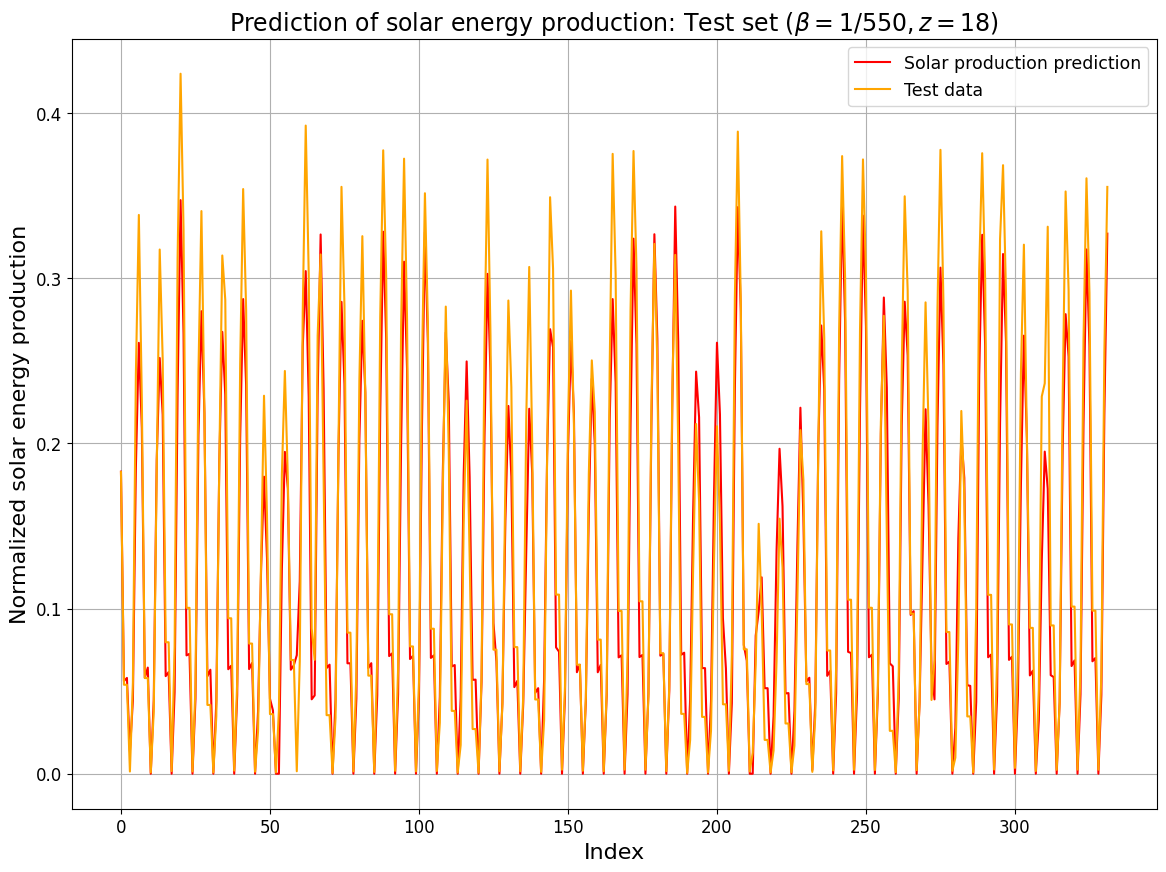

In [61]:
# regression test prediction vs test data

plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})


plt.figure(figsize=(14, 10))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5)],color='red',label='Solar production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5)],color='orange',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized solar energy production")
plt.title(r"Prediction of solar energy production: Test set ($\beta=1/550,z=18$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/best_model_solar_23_June_beta_1_550_z_18.png", dpi=300, bbox_inches='tight')
plt.show()

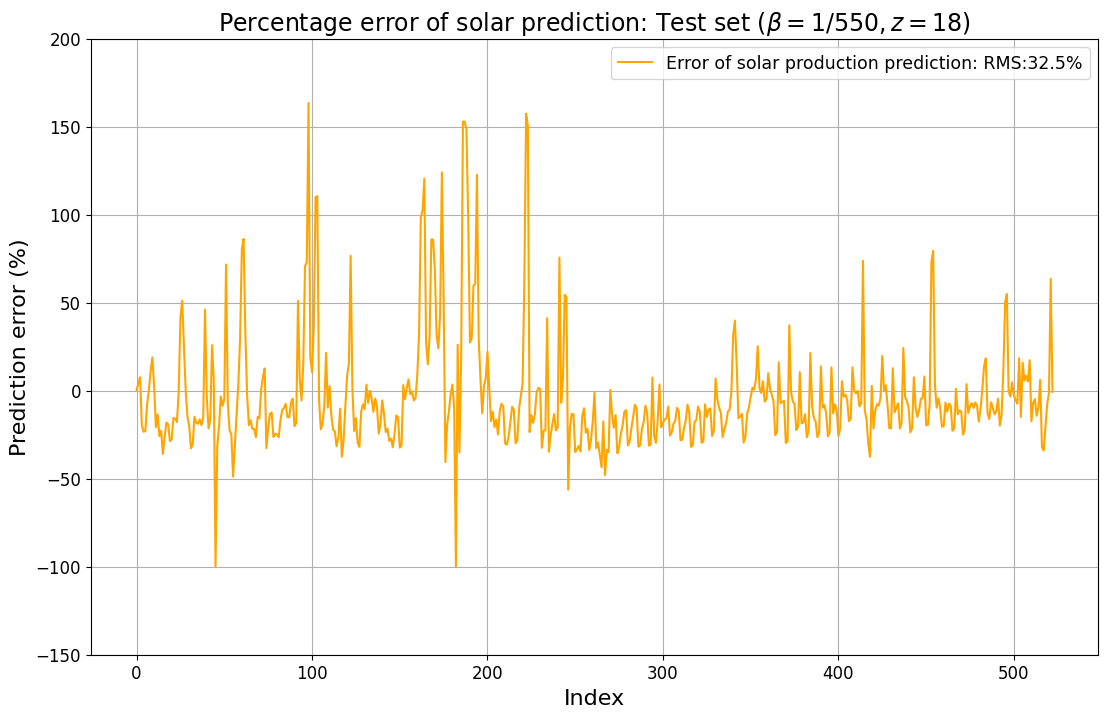

In [65]:
plt.figure(figsize=(13, 8))

Y_test_pos = Y_test[Y_test>=0.01]
error_solar= (mean_test_predictions[Y_test >= 0.01][:int(len(Y_test_pos)/2)]- Y_test_pos[:int(len(Y_test_pos)/2)]) / Y_test_pos[:int(len(Y_test_pos)/2)]
plt.plot(np.arange(int(len(Y_test_pos)/2)), (error_solar*100), color='orange', label=f'Error of solar production prediction: RMS:{round(np.sqrt(np.mean((error_solar*100)**2)),1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of solar prediction: Test set ($\beta=1/550,z=18$)")
plt.grid(True)
plt.ylim(-150,200)
plt.legend()
plt.savefig("plots/Solar_predictions/error_best_model_solar_23_June_beta_1_550_z_18_trial_2.png", dpi=600, bbox_inches='tight')
plt.show()


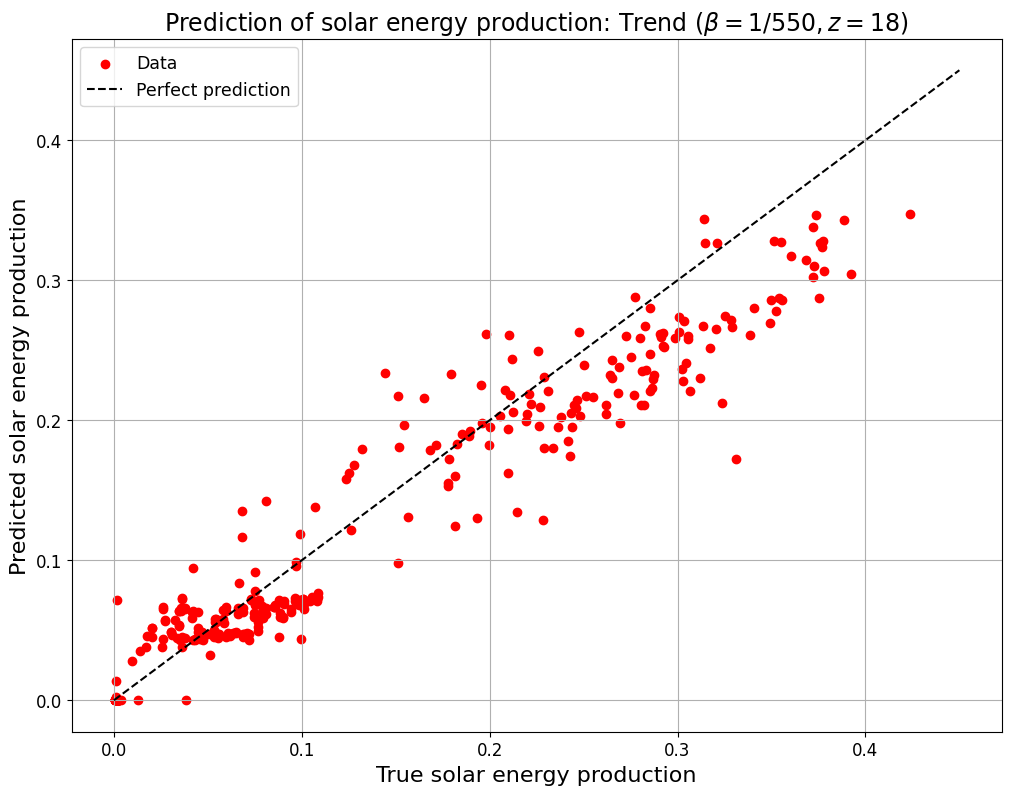

In [64]:
plt.figure(figsize=(12, 9))
plt.scatter(Y_test[:int(len(Y_test)/5)],mean_test_predictions[:int(len(mean_test_predictions)/5)],color='red',label='Data')
plt.xlabel("True solar energy production")
plt.plot(np.array(np.linspace(0,0.45,1000)),np.array(np.linspace(0,0.45,1000)),label='Perfect prediction',color='black',linestyle='--')
plt.ylabel("Predicted solar energy production")
plt.title(r"Prediction of solar energy production: Trend ($\beta=1/550,z=18$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/best_model_solar_trend_23_June_beta_1_550_z_18_trial_2.png", dpi=300, bbox_inches='tight')
plt.show()

## VAE Feature reconstruction

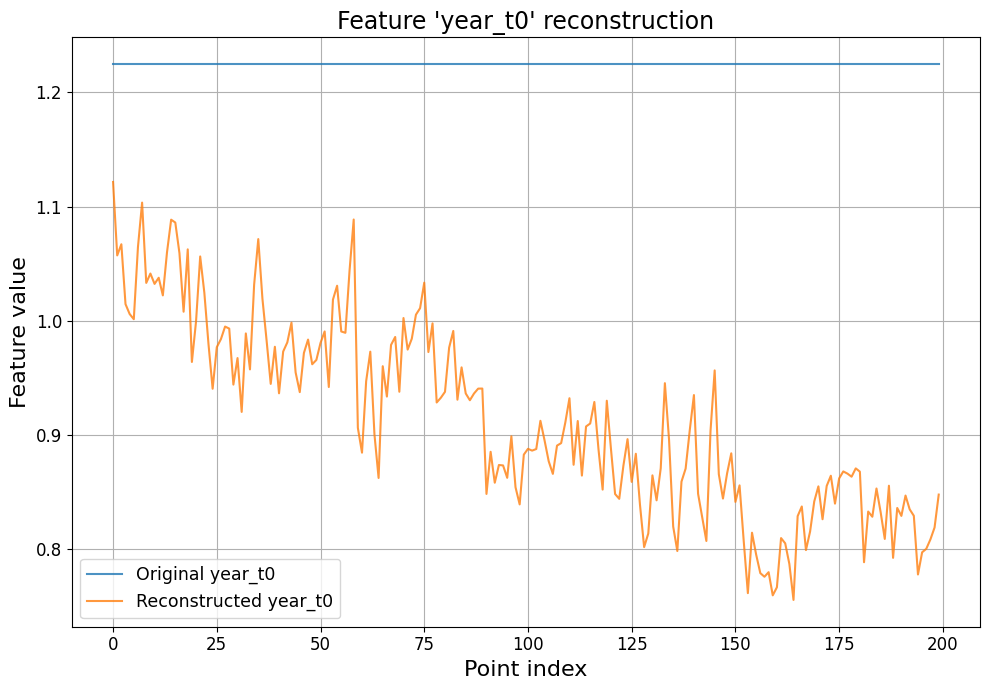

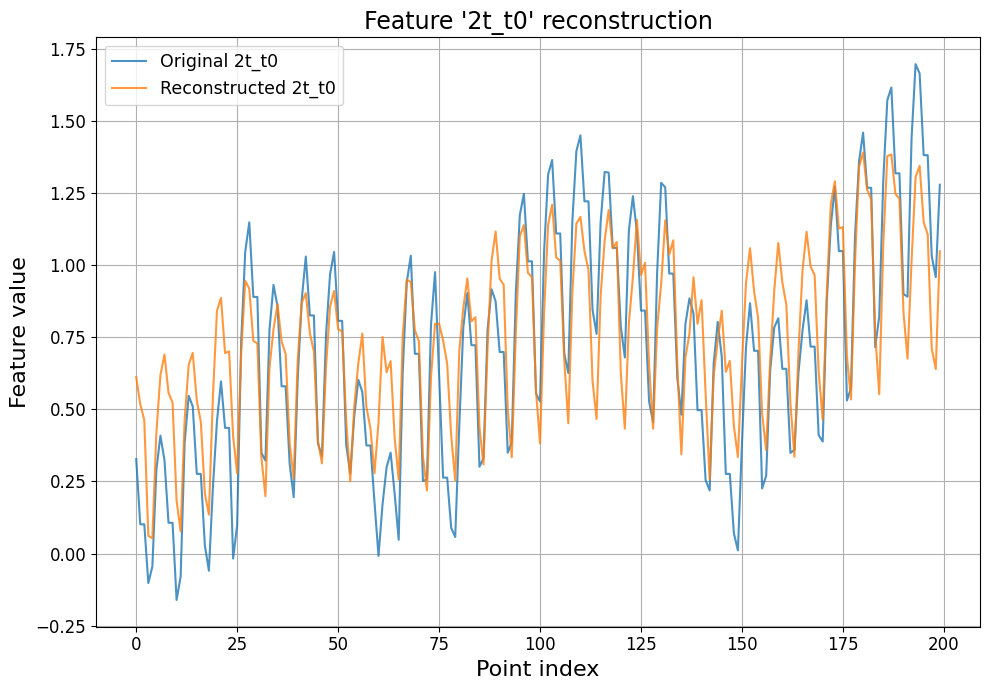

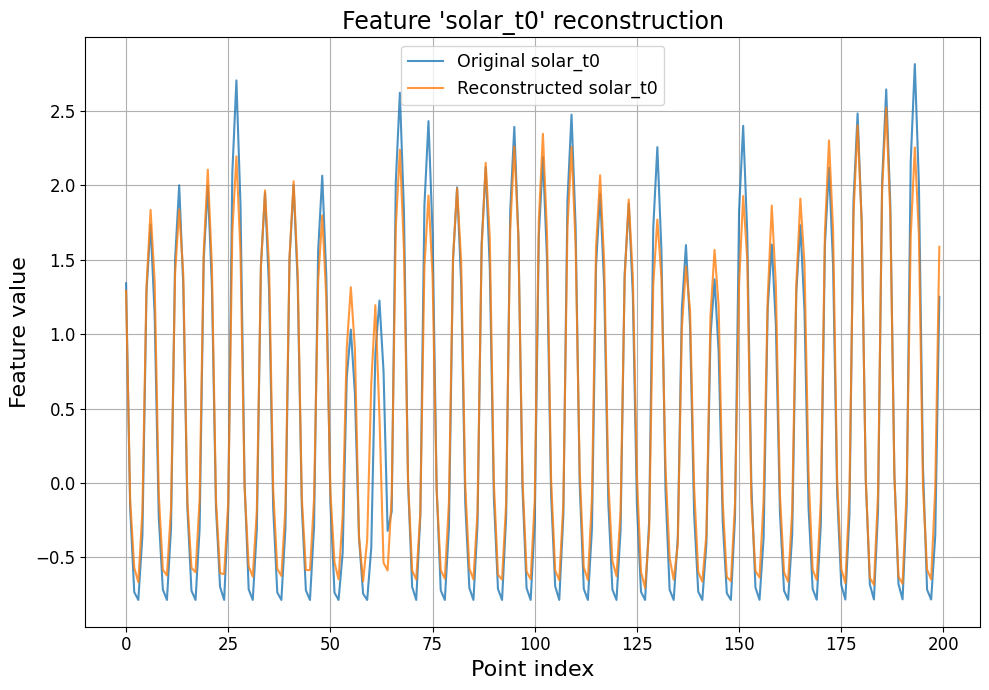

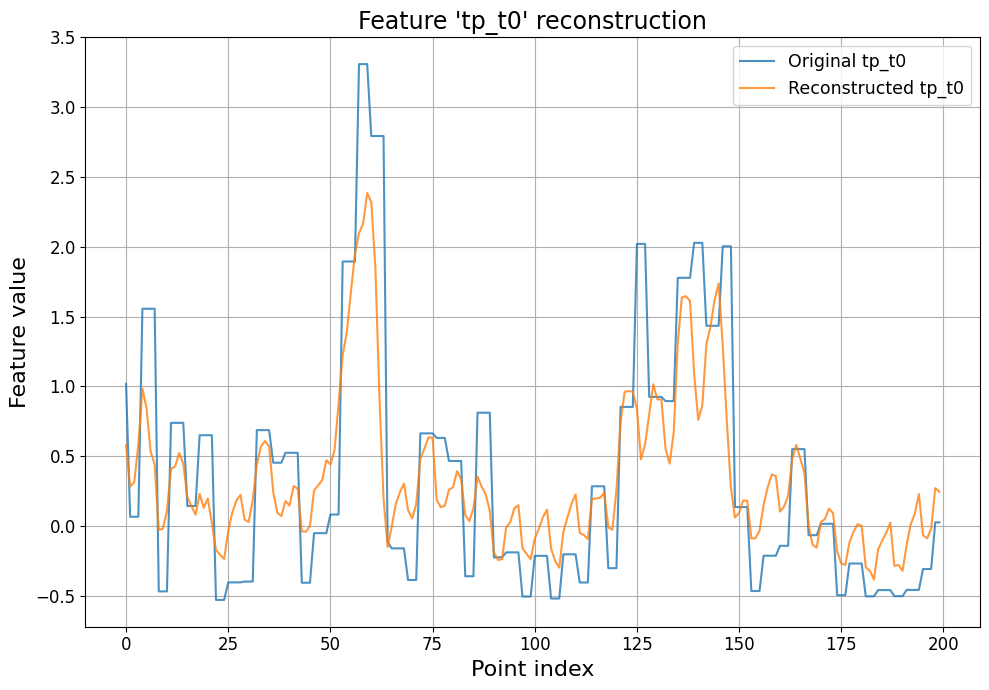

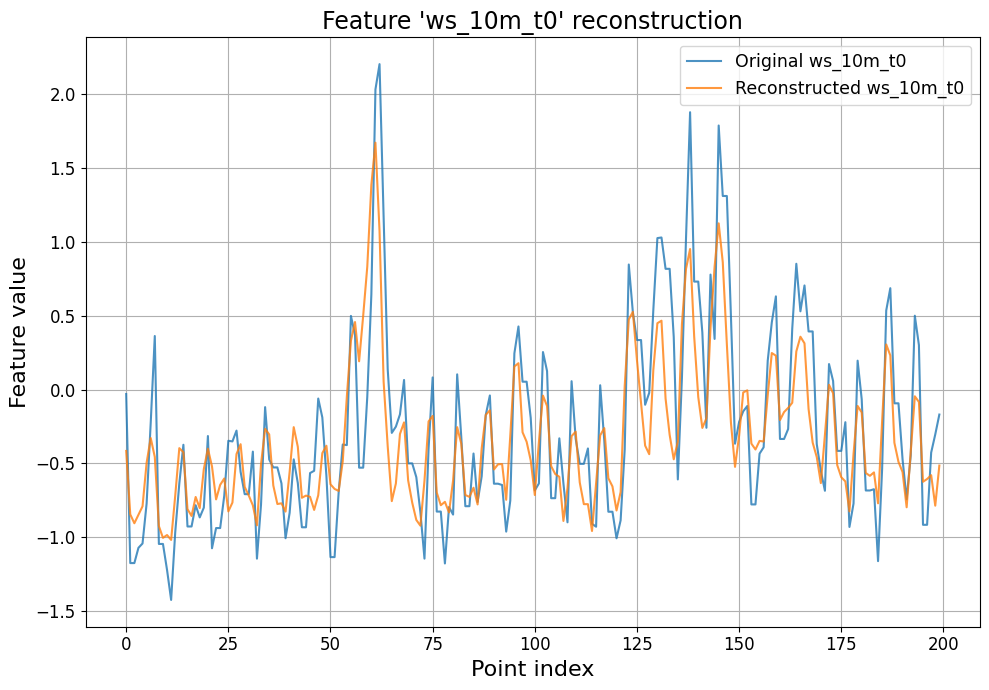

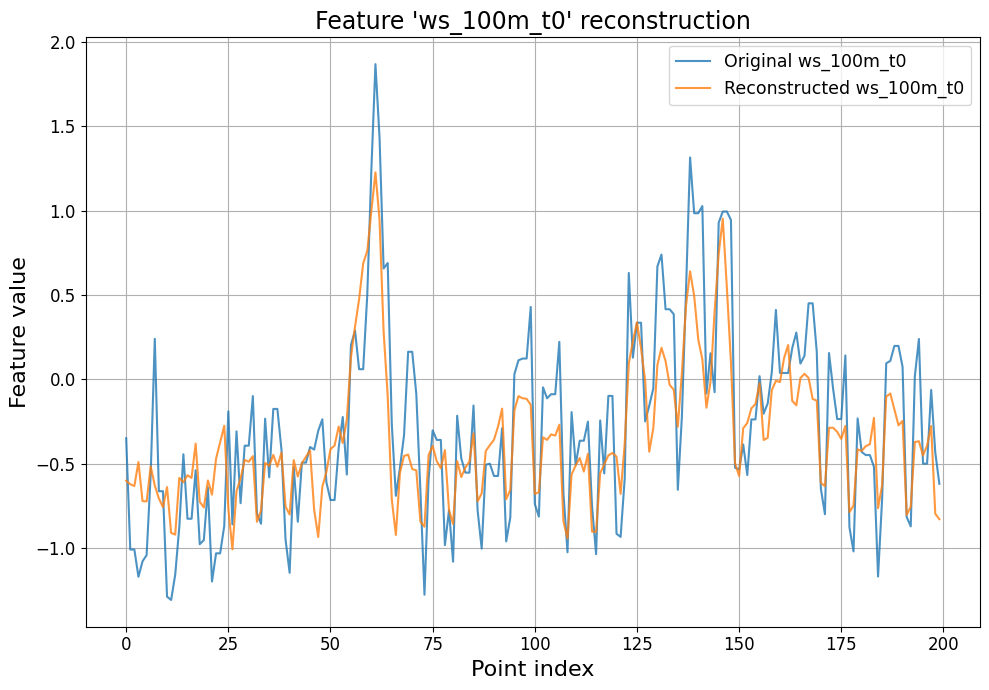

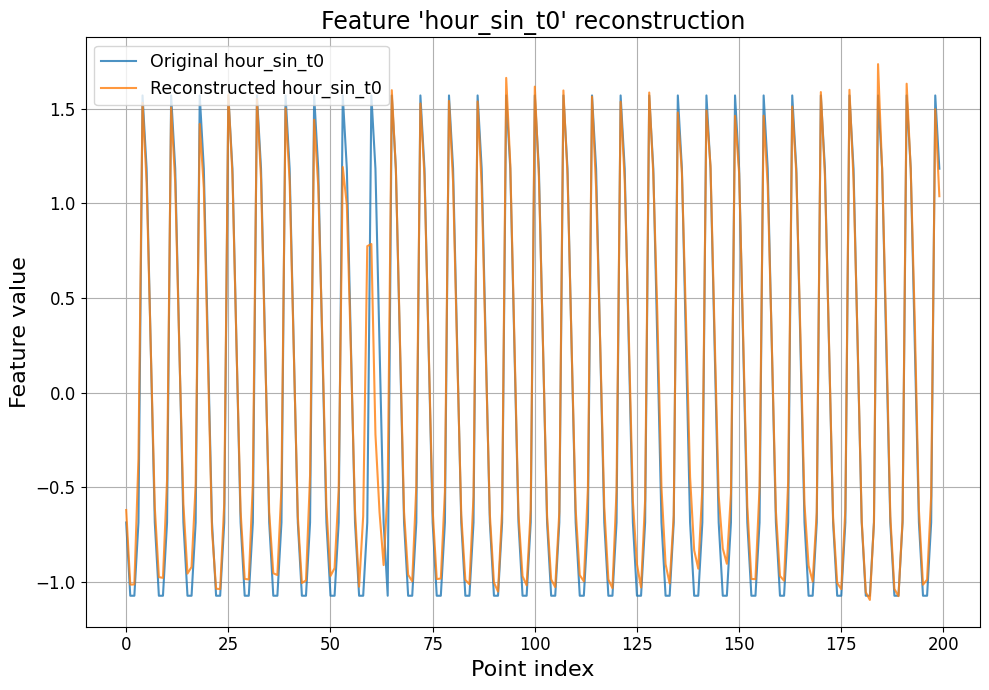

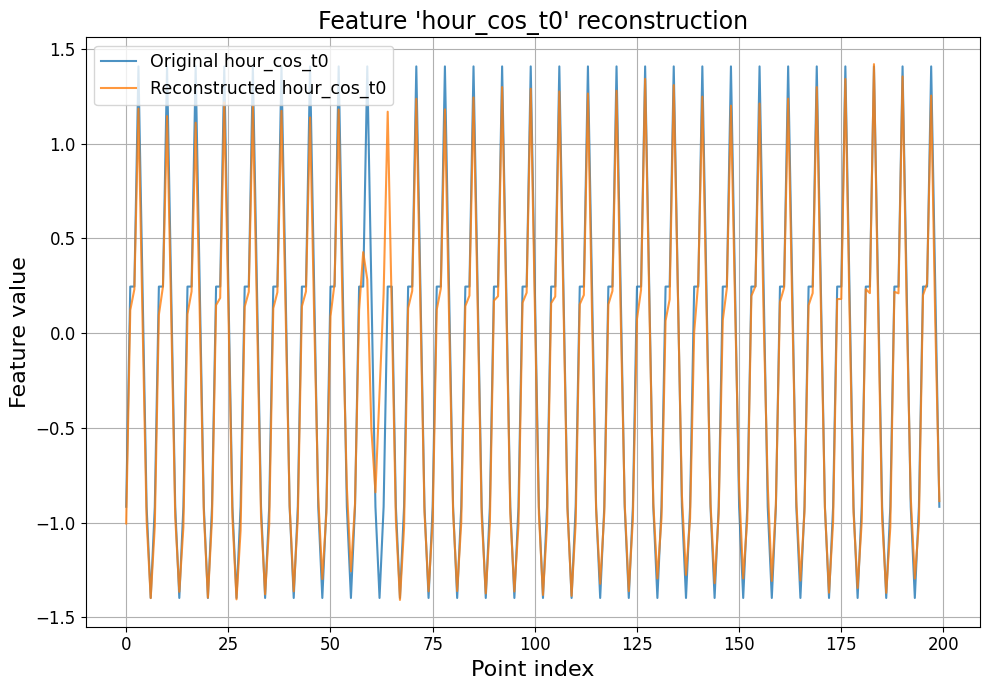

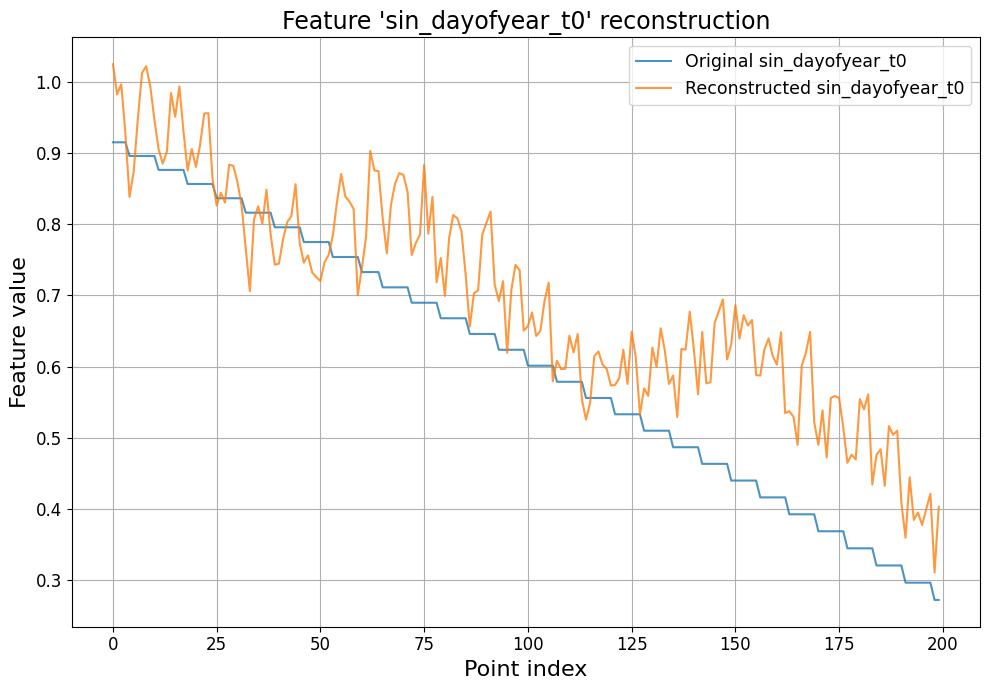

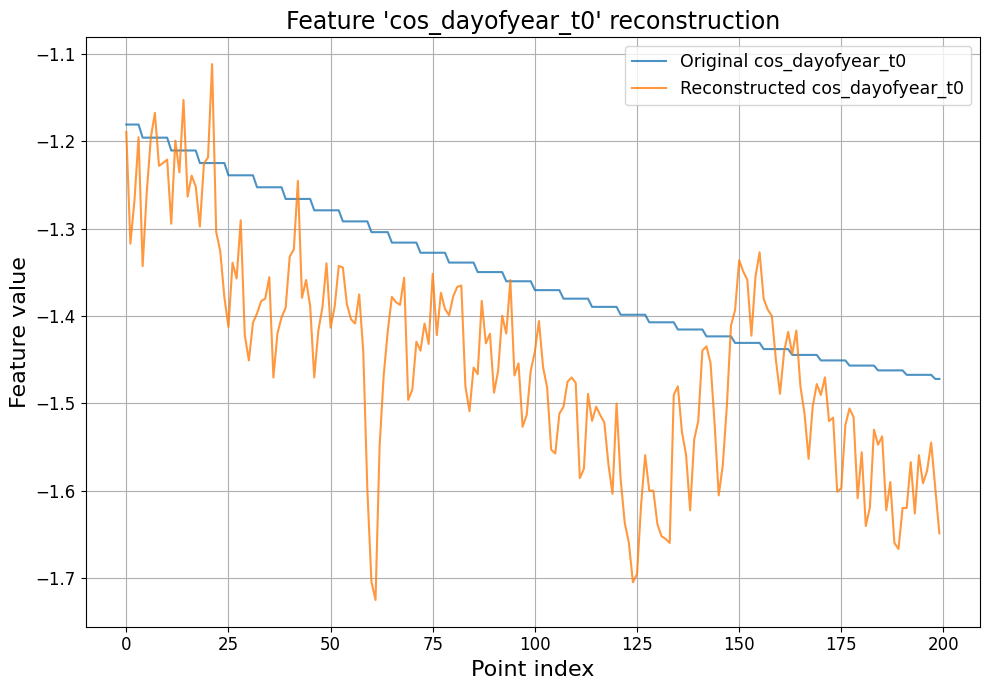

In [48]:
original_all = X_test
reconstructed_all = mean_recon_x_test

# Feature names from dataframe (excluding 'timestamp')
feature_names = df_features.drop(columns=['timestamp']).columns.tolist()

# Select features by index
features_to_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# How many time steps to plot
points_to_plot = 200
dummy_x = np.arange(points_to_plot)

for feature_idx in features_to_plot:
    plt.figure(figsize=(10, 7))

    plt.plot(dummy_x,
             original_all[:points_to_plot, feature_idx],
             alpha=0.8,
             label=f'Original {feature_names[feature_idx]}')

    plt.plot(dummy_x,
             reconstructed_all[:points_to_plot, feature_idx],
             alpha=0.8,
             label=f'Reconstructed {feature_names[feature_idx]}')

    plt.xlabel("Point index")
    plt.ylabel("Feature value")
    plt.title(f"Feature '{feature_names[feature_idx]}' reconstruction")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    filename = f'plots/VAE_Reconstruction/best_model_12_June_feature_{feature_idx}_beta_1_550_z_18_solar_2VAElayers_trial_2.png'
   # plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

## **Final training and results: wind**

In [86]:

# final training for the best hyper-parameters found

import os
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lambda_tik = 3.9022620018270354e-05
best_model = VAE_Regression(
    input_dim      = X_train_tensor.shape[1],
    hidden_dim1    = 256,
    hidden_dim2    = 64,
    latent_dim     = 18,
    hidden_dim3    = 256,
    vae_activation = get_activation("relu"),
    N1             = 256,
    N2             = 64,
    No             = Y_train_tensor.shape[1],
    activation     = get_activation("relu"),
    lambda_tik     =  lambda_tik
).to(device)

train_loader = DataLoader(TensorDataset(X_train_tensor, Y_train_tensor), batch_size=16, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  Y_test_tensor),  batch_size=16, shuffle=False)

num_epochs = 250
beta = 1./2100 # best previously found
patience = 35

train_curve     = []
test_curve      = []
test_vae_curve  = []
test_regr_curve = []

optimizer = torch.optim.Adam(best_model.parameters(), lr=5.937967528097218e-05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=20)


best_test = float("inf")
no_imp    = 0
best_state= None

for ep in range(num_epochs):
    best_model.train()
    train_sum = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred, recon, mu, logvar, _ = best_model(xb)
        vl = best_model.VAE_loss(recon, xb, mu, logvar)[0]
        rl = best_model.regression_loss(yb, pred, lambda_tik)
        loss = (1-beta)*rl + beta*vl
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(best_model.parameters(), 1.0)
        optimizer.step()
        train_sum += loss.item()
    train_curve.append(train_sum/len(train_loader))

    best_model.eval()
    t_sum = v_sum = r_sum = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred, recon, mu, logvar, _ = best_model(xb)
            vl = best_model.VAE_loss(recon, xb, mu, logvar)[0].item()
            rl = best_model.regression_loss(yb, pred,lambda_tik).item()
            t_sum += (1-beta)*rl + beta*vl
            v_sum += vl
            r_sum += rl
    te = t_sum/len(test_loader)
    tv = v_sum/len(test_loader)
    tr = r_sum/len(test_loader)
    test_curve.append(te)
    test_vae_curve.append(tv)
    test_regr_curve.append(tr)

    print(f"Epoch {ep+1}/{num_epochs} - Val Total: {te:.4f}, VAE: {tv:.4f}, Regr: {tr:.4f}")


    if tr < best_test:
        best_test = tr
        best_state= best_model.state_dict()
        no_imp    = 0
    else:
        no_imp += 1
        if no_imp >= patience:
            break

best_model.load_state_dict(best_state)
os.makedirs("best_Regr_models/Single_wind", exist_ok=True)
torch.save(best_state, "best_Regr_models/Single_wind/best_model_wind_23June_FINAL.pt")

train_loss_curve    = np.array(train_curve)
val_loss_curve      = np.array(test_curve)
val_vae_loss_curve  = np.array(test_vae_curve)
val_regr_loss_curve = np.array(test_regr_curve)


Epoch 1/250 - Val Total: 50.8141, VAE: 1727.1749, Regr: 50.0154
Epoch 2/250 - Val Total: 34.3888, VAE: 1718.3332, Regr: 33.5866
Epoch 3/250 - Val Total: 25.2172, VAE: 1701.8000, Regr: 24.4185
Epoch 4/250 - Val Total: 19.5128, VAE: 1697.4586, Regr: 18.7133
Epoch 5/250 - Val Total: 15.6693, VAE: 1699.2513, Regr: 14.8672
Epoch 6/250 - Val Total: 12.7022, VAE: 1690.2517, Regr: 11.9030
Epoch 7/250 - Val Total: 10.5382, VAE: 1668.8640, Regr: 9.7482
Epoch 8/250 - Val Total: 8.8260, VAE: 1659.9576, Regr: 8.0394
Epoch 9/250 - Val Total: 7.5421, VAE: 1653.3471, Regr: 6.7580
Epoch 10/250 - Val Total: 6.4492, VAE: 1610.5219, Regr: 5.6850
Epoch 11/250 - Val Total: 5.7339, VAE: 1596.9652, Regr: 4.9758
Epoch 12/250 - Val Total: 5.0229, VAE: 1575.4352, Regr: 4.2747
Epoch 13/250 - Val Total: 4.6308, VAE: 1565.5408, Regr: 3.8872
Epoch 14/250 - Val Total: 4.3513, VAE: 1571.4537, Regr: 3.6047
Epoch 15/250 - Val Total: 4.0529, VAE: 1541.6200, Regr: 3.3204
Epoch 16/250 - Val Total: 3.9139, VAE: 1549.6332, R

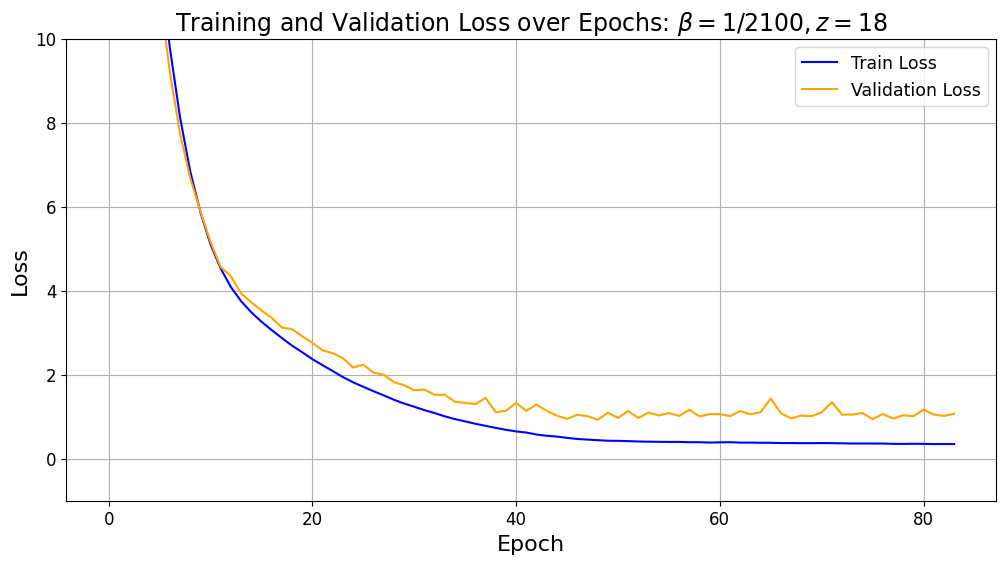

In [16]:
epochs = np.arange(len(train_loss_curve[train_loss_curve!=0]))

plt.figure(figsize=(12, 6))


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})

plt.plot(epochs, train_loss_curve[train_loss_curve!=0], label='Train Loss', color='blue')
plt.plot(epochs, val_loss_curve[val_loss_curve!=0], label='Validation Loss', color='orange')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(r"Training and Validation Loss over Epochs: $\beta=1/2100,z=18$")
plt.legend()
plt.ylim(-1,10)
plt.grid(True)
plt.savefig("plots/Wind_predictions/best_model_wind_23_June_loss_beta_1_2100_z_18.png", dpi=300, bbox_inches='tight')
plt.show()

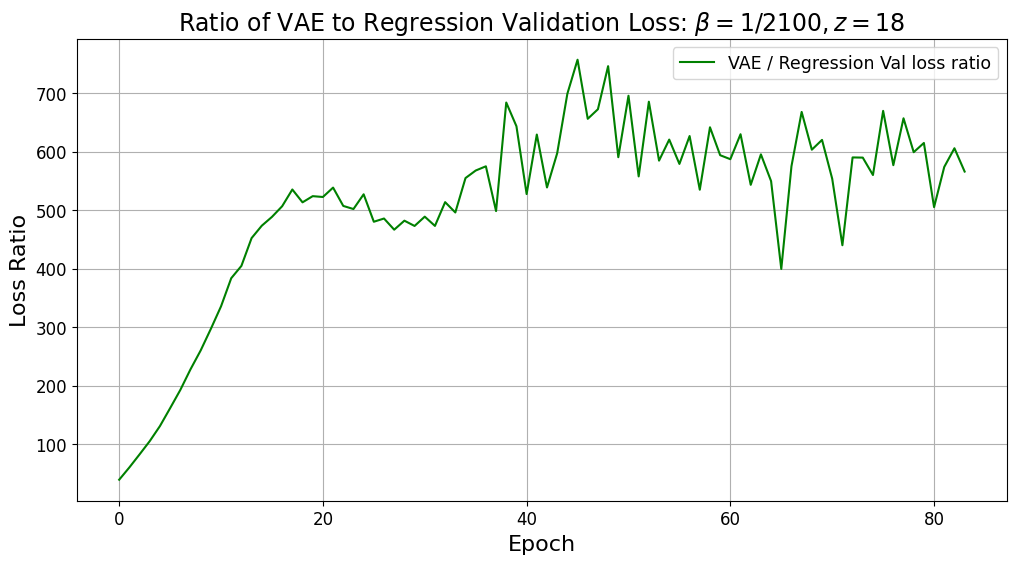

In [17]:
loss_ratio = val_vae_loss_curve / (val_regr_loss_curve + 1e-9)  # avoid division by zero

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_ratio[:len(epochs)], label='VAE / Regression Val loss ratio', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss Ratio")
plt.title(r"Ratio of VAE to Regression Validation Loss: $\beta=1/2100,z=18$")
plt.grid(True)
plt.legend()
plt.savefig("plots/Wind_predictions/best_model_wind_23_June_Ratio_beta_1_2100_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()

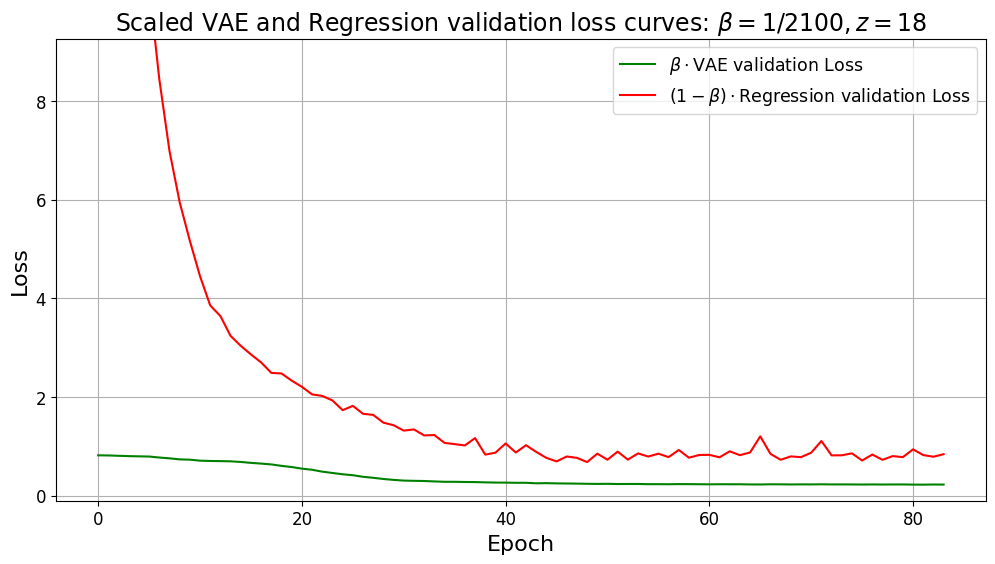

In [19]:
fig,ax= plt.subplots(figsize=(12,6))
beta = 1./2100
ax.plot(epochs, beta*val_vae_loss_curve[:len(epochs)], label=r'$\beta \cdot$VAE validation Loss', color='green')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(r"Scaled VAE and Regression validation loss curves: $\beta=1/2100,z=18$")

ax.plot(epochs, (1-beta)*val_regr_loss_curve[:len(epochs)], label=r'$(1-\beta)\cdot$Regression validation Loss', color='red')
plt.ylim(-0.1,10*np.min(val_loss_curve[:len(epochs)]))
ax.grid(True)
ax.legend()
plt.savefig("plots/Wind_predictions/best_model_wind_23_June_Vae_Regr_Losses_beta_1_2100_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()


In [87]:
# predictions

best_model.eval()

num_passes= 100

mean_preds = None

for i in range(num_passes):
    regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    regr_output = regr_output.cpu()
    recon_x = recon_x.cpu()

    if mean_preds is None:
        mean_preds = regr_output
        mean_recons = recon_x
    else:
        mean_preds += (regr_output - mean_preds) / (i + 1)
        mean_recons += (recon_x - mean_recons) / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
mean_recon_x_test = mean_recons.detach().numpy()



print(mean_test_predictions)


[[0.05180195]
 [0.04353664]
 [0.07017823]
 ...
 [0.05220098]
 [0.05612546]
 [0.08010244]]


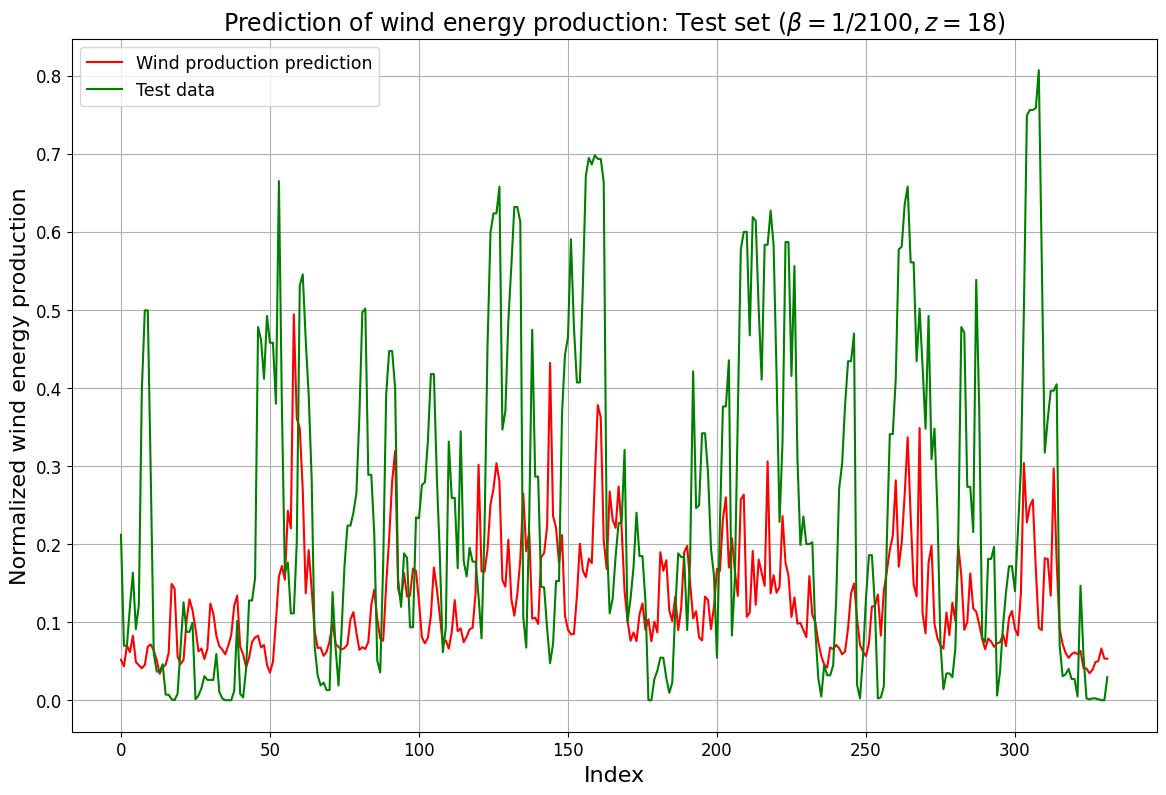

In [89]:
# regression test prediction vs test data

plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})


plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5)],color='red',label='Wind production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5)],color='green',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized wind energy production")
plt.title(r"Prediction of wind energy production: Test set ($\beta=1/2100,z=18$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Wind_predictions/best_model_wind_23_June_beta_1_2100_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()


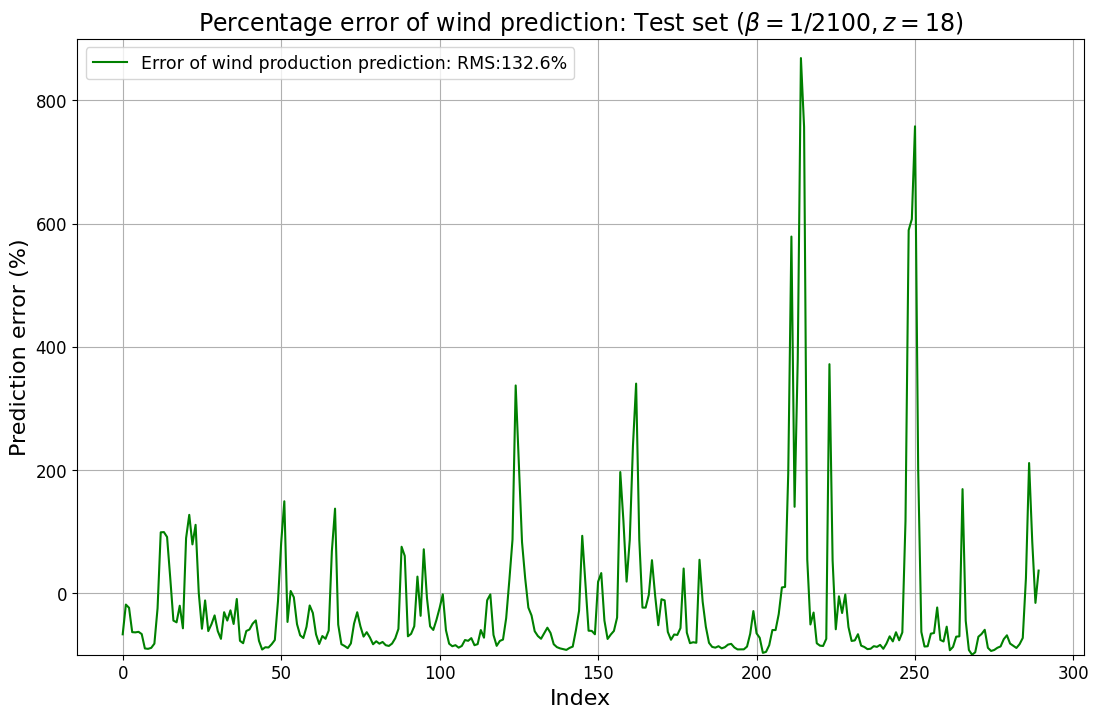

In [83]:
plt.figure(figsize=(13, 8))

Y_test_pos = Y_test[Y_test>=0.02]
error_wind= (mean_test_predictions[Y_test >= 0.05][:int(len(Y_test_pos)/5)]- Y_test_pos[:int(len(Y_test_pos)/5)]) / Y_test_pos[:int(len(Y_test_pos)/5)]
plt.plot(np.arange(int(len(Y_test_pos)/5)), (error_wind*100), color='green', label=f'Error of wind production prediction: RMS:{round(np.sqrt(np.mean((error_wind*100)**2)),1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of wind prediction: Test set ($\beta=1/2100,z=18$)")
plt.grid(True)
plt.ylim(-100,900)
plt.legend()
plt.savefig("plots/Wind_predictions/error_best_model_wind_23_June_beta_1_2100_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()

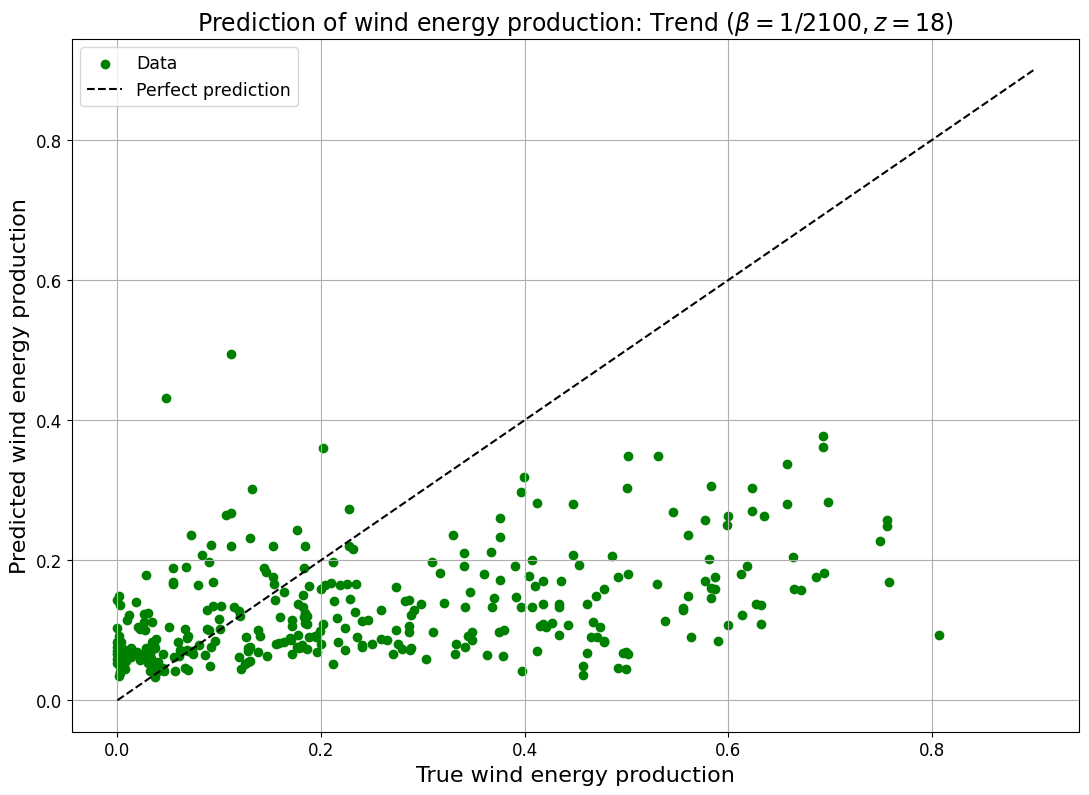

In [90]:
plt.figure(figsize=(13, 9))
plt.scatter(Y_test[:int(len(Y_test)/5)],mean_test_predictions[:int(len(mean_test_predictions)/5)],color='green',label='Data')
plt.xlabel("True wind energy production")
plt.plot(np.array(np.linspace(0,0.9,1000)),np.array(np.linspace(0,0.9,1000)),label='Perfect prediction',color='black',linestyle='--')
plt.ylabel("Predicted wind energy production")
plt.title(r"Prediction of wind energy production: Trend ($\beta=1/2100,z=18$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Wind_predictions/best_model_wind_trend_23_June_beta_1_2100_z_18.png", dpi=300, bbox_inches='tight')
plt.show()

## **Final training and reuslts: hydro-electric**


In [98]:


# final training for the best hyper-parameters found

import os
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lambda_tik = 3.9022620018270354e-05
best_model = VAE_Regression(
    input_dim      = X_train_tensor.shape[1],
    hidden_dim1    = 256,
    hidden_dim2    = 64,
    latent_dim     = 18,
    hidden_dim3    = 256,
    vae_activation = get_activation("relu"),
    N1             = 256,
    N2             = 64,
    No             = Y_train_tensor.shape[1],
    activation     = get_activation("relu"),
    lambda_tik     =  lambda_tik
).to(device)

train_loader = DataLoader(TensorDataset(X_train_tensor, Y_train_tensor), batch_size=16, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  Y_test_tensor),  batch_size=16, shuffle=False)

num_epochs = 250
beta = 1./1000 # best previously found
patience = 35

train_curve     = []
test_curve      = []
test_vae_curve  = []
test_regr_curve = []

optimizer = torch.optim.Adam(best_model.parameters(), lr=5.937967528097218e-05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=20)


best_test = float("inf")
no_imp    = 0
best_state= None

for ep in range(num_epochs):
    best_model.train()
    train_sum = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred, recon, mu, logvar, _ = best_model(xb)
        vl = best_model.VAE_loss(recon, xb, mu, logvar)[0]
        rl = best_model.regression_loss(yb, pred, lambda_tik)
        loss = (1-beta)*rl + beta*vl
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(best_model.parameters(), 1.0)
        optimizer.step()
        train_sum += loss.item()
    train_curve.append(train_sum/len(train_loader))

    best_model.eval()
    t_sum = v_sum = r_sum = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred, recon, mu, logvar, _ = best_model(xb)
            vl = best_model.VAE_loss(recon, xb, mu, logvar)[0].item()
            rl = best_model.regression_loss(yb, pred,lambda_tik).item()
            t_sum += (1-beta)*rl + beta*vl
            v_sum += vl
            r_sum += rl
    te = t_sum/len(test_loader)
    tv = v_sum/len(test_loader)
    tr = r_sum/len(test_loader)
    test_curve.append(te)
    test_vae_curve.append(tv)
    test_regr_curve.append(tr)

    print(f"Epoch {ep+1}/{num_epochs} - Val Total: {te:.4f}, VAE: {tv:.4f}, Regr: {tr:.4f}")


    if tr < best_test:
        best_test = tr
        best_state= best_model.state_dict()
        no_imp    = 0
    else:
        no_imp += 1
        if no_imp >= patience:
            break

best_model.load_state_dict(best_state)
#os.makedirs("best_Regr_models/Single_hydro", exist_ok=True)
#torch.save(best_state, "best_Regr_models/Single_hydro/best_model_hydro_23June_FINAL.pt")

train_loss_curve    = np.array(train_curve)
val_loss_curve      = np.array(test_curve)
val_vae_loss_curve  = np.array(test_vae_curve)
val_regr_loss_curve = np.array(test_regr_curve)



Epoch 1/250 - Val Total: 51.1243, VAE: 1722.1935, Regr: 49.4516
Epoch 2/250 - Val Total: 34.4155, VAE: 1709.9251, Regr: 32.7383
Epoch 3/250 - Val Total: 25.3278, VAE: 1698.9841, Regr: 23.6525
Epoch 4/250 - Val Total: 19.6653, VAE: 1698.7274, Regr: 17.9846
Epoch 5/250 - Val Total: 15.7233, VAE: 1676.7767, Regr: 14.0606
Epoch 6/250 - Val Total: 12.7137, VAE: 1671.2363, Regr: 11.0535
Epoch 7/250 - Val Total: 10.5076, VAE: 1640.7774, Regr: 8.8757
Epoch 8/250 - Val Total: 8.8847, VAE: 1580.0597, Regr: 7.3119
Epoch 9/250 - Val Total: 7.5772, VAE: 1500.7245, Regr: 6.0825
Epoch 10/250 - Val Total: 6.4802, VAE: 1425.9387, Regr: 5.0593
Epoch 11/250 - Val Total: 5.8957, VAE: 1389.6825, Regr: 4.5105
Epoch 12/250 - Val Total: 5.0668, VAE: 1299.6446, Regr: 3.7710
Epoch 13/250 - Val Total: 4.4716, VAE: 1171.5045, Regr: 3.3034
Epoch 14/250 - Val Total: 4.0752, VAE: 1064.9113, Regr: 3.0133
Epoch 15/250 - Val Total: 3.7469, VAE: 979.7815, Regr: 2.7699
Epoch 16/250 - Val Total: 3.5071, VAE: 879.9847, Reg

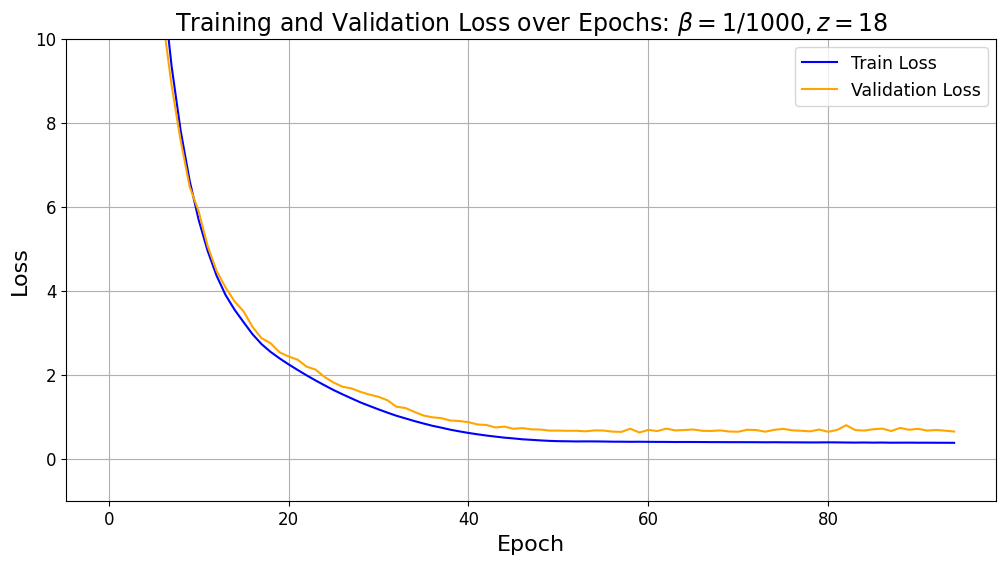

In [104]:
epochs = np.arange(len(train_loss_curve[train_loss_curve!=0]))

plt.figure(figsize=(12, 6))


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})

plt.plot(epochs, train_loss_curve[train_loss_curve!=0], label='Train Loss', color='blue')
plt.plot(epochs, val_loss_curve[val_loss_curve!=0], label='Validation Loss', color='orange')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(r"Training and Validation Loss over Epochs: $\beta=1/1000,z=18$")
plt.legend()
plt.ylim(-1,10)
plt.grid(True)
#plt.savefig("plots/Hydro_predictions/best_model_hydro_23_June_loss_beta_1_2100_z_18.png", dpi=300, bbox_inches='tight')
plt.show()

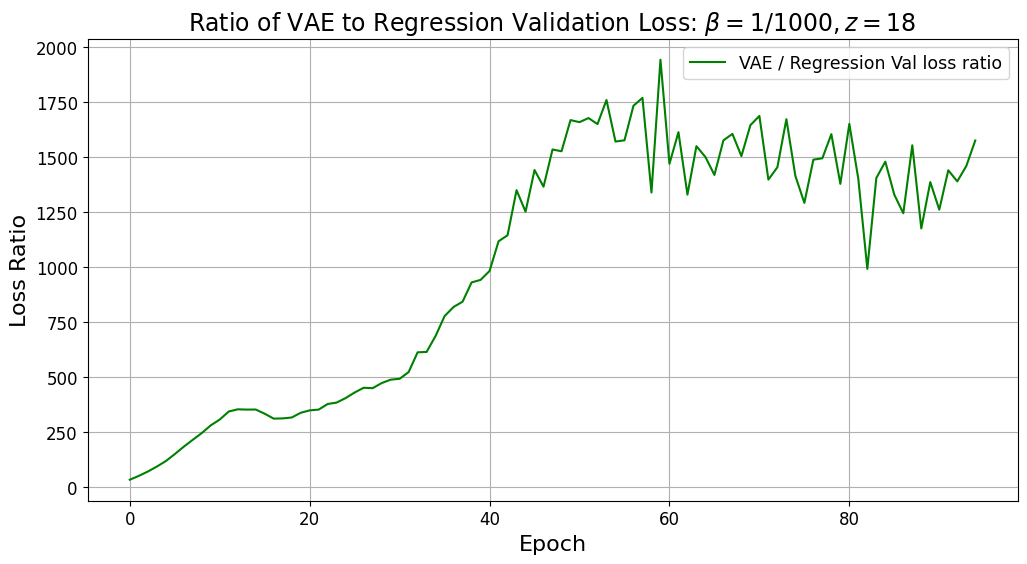

In [105]:
loss_ratio = val_vae_loss_curve / (val_regr_loss_curve + 1e-9)  # avoid division by zero

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_ratio[:len(epochs)], label='VAE / Regression Val loss ratio', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss Ratio")
plt.title(r"Ratio of VAE to Regression Validation Loss: $\beta=1/1000,z=18$")
plt.grid(True)
plt.legend()
#plt.savefig("plots/Hydro_predictions/best_model_hydro_23_June_Ratio_beta_1_550_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()

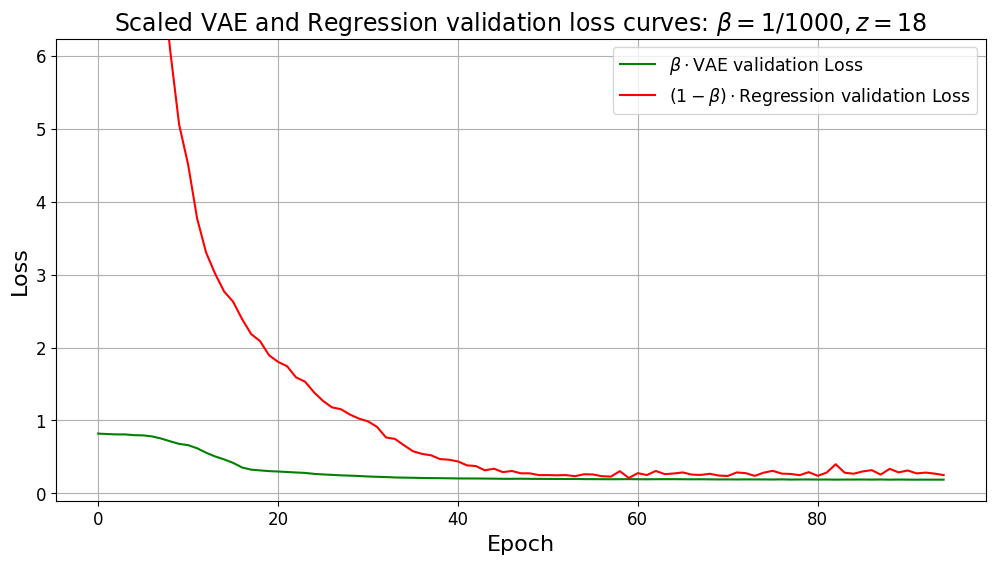

In [106]:
fig,ax= plt.subplots(figsize=(12,6))
beta = 1./2100
ax.plot(epochs, beta*val_vae_loss_curve[:len(epochs)], label=r'$\beta \cdot$VAE validation Loss', color='green')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(r"Scaled VAE and Regression validation loss curves: $\beta=1/1000,z=18$")

ax.plot(epochs, (1-beta)*val_regr_loss_curve[:len(epochs)], label=r'$(1-\beta)\cdot$Regression validation Loss', color='red')
plt.ylim(-0.1,10*np.min(val_loss_curve[:len(epochs)]))
ax.grid(True)
ax.legend()
#plt.savefig("plots/Hydro_predictions/best_model_hydro_23_June_Vae_Regr_Losses_beta_1_2100_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()


In [99]:
# predictions

best_model.eval()

num_passes= 100

mean_preds = None

for i in range(num_passes):
    regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    regr_output = regr_output.cpu()
    recon_x = recon_x.cpu()

    if mean_preds is None:
        mean_preds = regr_output
        mean_recons = recon_x
    else:
        mean_preds += (regr_output - mean_preds) / (i + 1)
        mean_recons += (recon_x - mean_recons) / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
mean_recon_x_test = mean_recons.detach().numpy()



print(mean_test_predictions)


[[0.43414384]
 [0.5297971 ]
 [0.5225628 ]
 ...
 [0.3465302 ]
 [0.28417677]
 [0.18136677]]


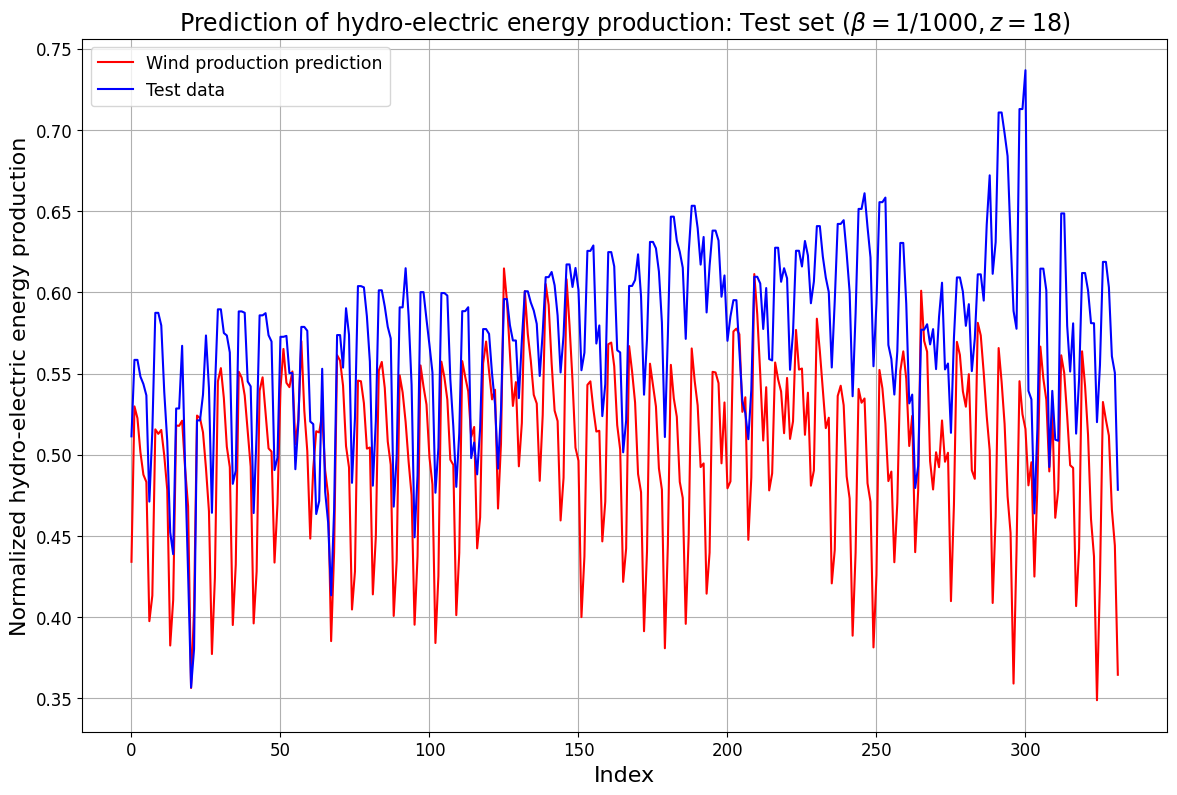

In [107]:
# regression test prediction vs test data

plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})


plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5)],color='red',label='Wind production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5)],color='blue',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized hydro-electric energy production")
plt.title(r"Prediction of hydro-electric energy production: Test set ($\beta=1/1000,z=18$)")
plt.grid(True)
plt.legend()
#plt.savefig("plots/Hydro_predictions/best_model_hydro_23_June_beta_1_2100_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(13, 8))

Y_test_pos = Y_test[Y_test>=0.02]
error_hydro= (mean_test_predictions[Y_test >= 0.05][:int(len(Y_test_pos)/5)]- Y_test_pos[:int(len(Y_test_pos)/5)]) / Y_test_pos[:int(len(Y_test_pos)/5)]
plt.plot(np.arange(int(len(Y_test_pos)/5)), (error_hydro*100), color='blue', label=f'Error of hydro production prediction: RMS:{round(np.sqrt(np.mean((error_wind*100)**2)),1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of hydro-electric prediction: Test set ($\beta=1/2100,z=18$)")
plt.grid(True)
plt.ylim(-100,900)
plt.legend()
plt.savefig("plots/Hydro_predictions/error_best_model_hydro_23_June_beta_1_2100_z_18_new.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(13, 9))
plt.scatter(Y_test[:int(len(Y_test)/5)],mean_test_predictions[:int(len(mean_test_predictions)/5)],color='blue',label='Data')
plt.xlabel("True hydro-electric energy production")
plt.plot(np.array(np.linspace(0,0.9,1000)),np.array(np.linspace(0,0.9,1000)),label='Perfect prediction',color='black',linestyle='--')
plt.ylabel("Predicted hydro-electric energy production")
plt.title(r"Prediction of hydro-electric energy production: Trend ($\beta=1/2100,z=18$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Hydro_predictions/best_model_hydro_trend_23_June_beta_1_2100_z_18.png", dpi=300, bbox_inches='tight')
plt.show()